# ▶ Colab quick start

**Runtime → Run all.** Nothing else is required — the next two cells install the dependencies and
build `news_data.csv` from FNSPID automatically.

**Recommended:** set *Runtime → Change runtime type → T4 GPU* before running. It is free and cuts
FinBERT scoring from a few minutes to a few seconds. Everything works on CPU too, just slower.

Expected total runtime: **6–12 minutes on CPU, 4–7 minutes on GPU.** See the timing note at the
bottom of the setup cell output.

In [1]:
# ============================================================================
# Colab setup — installs what Colab does not already ship
# ============================================================================
# Colab already has numpy, pandas, scipy, matplotlib, statsmodels, sklearn,
# torch and transformers. Missing: vaderSentiment, and yfinance is often stale
# (its unofficial Yahoo endpoints break, so pin to the latest).
import subprocess, sys, importlib, os, time

IN_COLAB = "google.colab" in sys.modules

def pip_install(*pkgs, upgrade=False):
    cmd = [sys.executable, "-m", "pip", "install", "-q"]
    if upgrade:
        cmd.append("-U")
    cmd += list(pkgs)
    return subprocess.run(cmd, capture_output=True, text=True).returncode

t0 = time.time()
print("Installing dependencies (~1-2 min on a cold Colab runtime)...\n")

# Always upgrade yfinance: Yahoo changes its endpoints and old versions 404.
print("  yfinance (upgrading — old versions break on Yahoo's endpoints)...")
pip_install("yfinance", upgrade=True)

print("  vaderSentiment...")
pip_install("vaderSentiment")

# transformers/torch ship with Colab, but install if running elsewhere.
for mod, pkg in [("transformers", "transformers"), ("torch", "torch"),
                 ("statsmodels", "statsmodels"), ("pyarrow", "pyarrow")]:
    try:
        importlib.import_module(mod)
        print(f"  {mod}: already present")
    except ImportError:
        print(f"  {mod}: installing...")
        pip_install(pkg)

print(f"\nInstalls finished in {time.time() - t0:.0f}s.\n")

# ---- report what we actually got, and whether a GPU is available ----------
def ver(m):
    try:
        return importlib.import_module(m).__version__
    except Exception:
        return "MISSING"

for m in ["numpy", "pandas", "scipy", "statsmodels", "sklearn",
          "yfinance", "transformers", "torch", "pyarrow"]:
    print(f"  {m:15s} {ver(m)}")
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    print(f"  {'vaderSentiment':15s} available")
except ImportError:
    print(f"  {'vaderSentiment':15s} MISSING — the VADER arm will be all zeros")

GPU = False
try:
    import torch
    GPU = torch.cuda.is_available()
except Exception:
    pass

print("\n" + "=" * 78)
print(f"  GPU: {'YES — ' + torch.cuda.get_device_name(0) if GPU else 'NO (CPU only)'}")
if not GPU:
    print("  Tip: Runtime > Change runtime type > T4 GPU makes FinBERT ~20x faster.")
print("=" * 78)
print("""
Expected timings from here:
  FNSPID fetch (next cell)   ~1-3 min   (first run only; cached afterwards)
  TSLA price download        ~5-15 sec
  FinBERT model download     ~1-2 min   (first run only, ~440MB)
  FinBERT scoring            GPU ~10-30 sec | CPU ~2-6 min
  Everything else            <1 min
If a cell sits silent for >5 min with no new output, something is stuck.""")

# IMPORTANT: if you just installed/upgraded packages in a fresh Colab runtime and
# a later import misbehaves, use Runtime > Restart session, then Run all again.

Installing dependencies (~1-2 min on a cold Colab runtime)...

  yfinance (upgrading — old versions break on Yahoo's endpoints)...
  vaderSentiment...
  transformers: already present
  torch: already present
  statsmodels: already present
  pyarrow: already present

Installs finished in 28s.

  numpy           2.0.2
  pandas          2.2.2
  scipy           1.16.3
  statsmodels     0.14.6
  sklearn         1.6.1
  yfinance        1.6.0
  transformers    5.13.1
  torch           2.11.0+cu128
  pyarrow         18.1.0
  vaderSentiment  available

  GPU: YES — Tesla T4

Expected timings from here:
  FNSPID fetch (next cell)   ~1-3 min   (first run only; cached afterwards)
  TSLA price download        ~5-15 sec
  FinBERT model download     ~1-2 min   (first run only, ~440MB)
  FinBERT scoring            GPU ~10-30 sec | CPU ~2-6 min
  Everything else            <1 min
If a cell sits silent for >5 min with no new output, something is stuck.


# Does News Sentiment Predict TSLA Returns?

A falsifiable test rather than a chart that looks suggestive: finance-tuned sentiment scoring,
strict timestamp discipline, HAC-corrected regressions, and a backtest with costs.

**Pipeline:** Data → Sentiment (FinBERT vs VADER) → Timestamp Alignment → Statistical Test →
Backtest with Costs → Robustness → Conclusion

---

## Read this before running: the data problem is the hard part

**`yfinance`'s news endpoint does not return years of history.** It returns roughly the last
10–20 articles. That is not a bug — Yahoo's endpoint is built to populate a "latest news" widget,
not to serve a research archive. A study built on it has an effective sample of a few days, which
cannot support any of the statistics below.

This matters enough to state plainly, because it is the single most common way this project
silently fails: people call the news API, get a small list back, don't check the date range, and
run a "3-year study" on two weeks of headlines.

The notebook therefore tries three sources in order and **reports which one it used**:

| Source | History | Notes |
|---|---|---|
| **1. Local CSV** (`news_data.csv`) | whatever you supply | The recommended path — see below |
| **2. `yfinance` news API** | ~last 10–20 articles | Used only if it clears the sample-size gate; usually it does not |
| **3. Synthetic generator** | configurable | **Loudly flagged.** Structure only, no real information |

### Getting real multi-year headlines

The best free option is **FNSPID** (Dong, Fan & Peng, KDD 2024) — 15.7M time-aligned financial news
records for 4,775 S&P 500 companies covering 1999–2023, from `github.com/Zdong104/FNSPID_Financial_News_Dataset`.
Filter to TSLA and save as `news_data.csv` with columns `timestamp` (ISO 8601, with timezone) and
`headline`.

Other workable sources: **Alpaca's news API** (free tier, Benzinga-sourced, history to 2015),
**GDELT** (free, no key), or a Kaggle financial-headlines dataset. Anything with a real timestamp
and multi-year coverage works — the notebook only needs those two columns.

**Whatever the source, the sample-size gate below decides whether the statistics are worth
reporting, and says so either way.**

## 0. Setup

In [2]:
# ============================================================================
# Imports and configuration
# ============================================================================
import os
import re
import sys
import time
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from scipy import stats

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ============================================================================
# CONFIG
# ============================================================================
TICKER = "TSLA"
# FNSPID news coverage ends in 2023, so the window stops there. Extending past
# the news range would leave months of prices with no headlines at all.
START_DATE, END_DATE = "2020-01-01", "2023-12-31"

NEWS_CSV = os.environ.get("NEWS_CSV", "news_data.csv")   # your headline file
PRICE_CSV = "price_data.csv"                              # price cache

MARKET_TZ = "America/New_York"
MARKET_CLOSE = "16:00"        # regular-session close, the cutoff for day-T information

# Sample-size gate: below this the statistics are not worth reporting.
MIN_HEADLINES = 500
MIN_DAYS_WITH_NEWS = 200

COST_BPS = 7.5                # round-trip transaction cost per trade, basis points
MIN_HOLD_DAYS = 1             # trade-frequency limit

# Optional dependencies -------------------------------------------------------
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    HAS_VADER = True
except ImportError:
    HAS_VADER = False

try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    import torch
    HAS_FINBERT_DEPS = True
except ImportError:
    HAS_FINBERT_DEPS = False

try:
    import yfinance as yf
    HAS_YF = True
except ImportError:
    HAS_YF = False

print(f"numpy {np.__version__} | pandas {pd.__version__} | statsmodels {sm.__version__}")
print(f"vaderSentiment  {'available' if HAS_VADER else 'MISSING — pip install vaderSentiment'}")
print(f"transformers+torch {'available' if HAS_FINBERT_DEPS else 'MISSING — pip install transformers torch'}")
print(f"yfinance        {'available' if HAS_YF else 'MISSING'}")

numpy 2.0.2 | pandas 2.2.2 | statsmodels 0.14.6
vaderSentiment  available
transformers+torch available
yfinance        available


## 0.5 Fetch real TSLA headlines (FNSPID)

This cell builds `news_data.csv` **only if it does not already exist**, so re-running the notebook
is cheap. The notebook's existing loader picks the file up automatically as its first-choice source.

**Why not the headline FNSPID file.** The canonical `nasdaq_exteral_data.csv` is **23.2 GB** — a
30–60 minute download that will not fit comfortably in a Colab session. TSLA is a NASDAQ-100
constituent, so this cell instead uses a pre-filtered NASDAQ-100 parquet export (825 MB total)
and reads **only 3 of its 12 columns**. Column projection means the actual transfer is tens of
megabytes, not gigabytes.

Three tiers, cheapest first, each printing progress:

| Tier | Source | Transfer | Notes |
|---|---|---|---|
| **A** | Parquet shards, 3 columns | ~20–60 MB | Default. Shard-by-shard, low peak RAM |
| **B** | HF `/filter` API, paginated | ~a few MB | Fallback. Light but request-heavy |
| **C** | Full 23.2 GB CSV, streamed | 23.2 GB | **Off by default.** Set `ALLOW_FULL_FNSPID = True` only for a non-NASDAQ-100 ticker |

If every tier fails, the file simply isn't written, and the notebook's sample-size gate and loud
synthetic banner take over exactly as before — nothing is bypassed or weakened.

In [3]:
# ============================================================================
# FNSPID -> news_data.csv   (runs only if news_data.csv is missing)
# ============================================================================
# Strategy, cheapest first. Each tier is memory-safe and prints progress.
#
#   Tier A  Parquet shards of benstaf/FNSPID-filtered-nasdaq-100 (825MB total),
#           reading ONLY the 3 columns we need. Column projection means we pull
#           roughly 20-60MB, not 825MB. Shard-by-shard, so peak RAM stays small.
#   Tier B  HF /filter API, paginated 100 rows at a time. Very light, no bulk
#           download, but slower per row and rate-limitable.
#   Tier C  The full 23.2GB FNSPID CSV, streamed in chunks. OFF by default --
#           it is a ~30-60 min download and unnecessary for a NASDAQ-100 name.
#
# If all tiers fail, news_data.csv is simply not created and the notebook's
# existing gate + synthetic fallback take over unchanged.
import io
import os
import sys
import time
import json
import urllib.request
import urllib.parse

import pandas as pd

TARGET_TICKER = "TSLA"
NEWS_CSV_OUT = "news_data.csv"

HF_DATASET = "benstaf/FNSPID-filtered-nasdaq-100"
HF_PARQUET_API = "https://datasets-server.huggingface.co/parquet?dataset="
HF_FILTER_API = "https://datasets-server.huggingface.co/filter"

# Tier C is a 23.2GB download. Set True only if A and B both fail and you
# specifically need a non-NASDAQ-100 ticker.
ALLOW_FULL_FNSPID = False
FULL_FNSPID_URL = ("https://huggingface.co/datasets/Zihan1004/FNSPID/"
                   "resolve/main/Stock_news/nasdaq_exteral_data.csv")

# Column aliases: FNSPID variants differ slightly across mirrors.
DATE_ALIASES = ["Date", "date", "publish_time", "timestamp"]
TITLE_ALIASES = ["Article_title", "article_title", "title", "headline"]
SYMBOL_ALIASES = ["Stock_symbol", "stock_symbol", "symbol", "ticker"]


def _pick(cols, aliases):
    lower = {str(c).lower(): c for c in cols}
    for a in aliases:
        if a.lower() in lower:
            return lower[a.lower()]
    return None


def _normalise(df, ticker=TARGET_TICKER):
    """Filter to the ticker and return a frame with timestamp + headline."""
    dcol = _pick(df.columns, DATE_ALIASES)
    tcol = _pick(df.columns, TITLE_ALIASES)
    scol = _pick(df.columns, SYMBOL_ALIASES)
    if dcol is None or tcol is None:
        return None
    out = df
    if scol is not None:
        out = out[out[scol].astype(str).str.upper().str.strip() == ticker]
    if len(out) == 0:
        return pd.DataFrame(columns=["timestamp", "headline"])
    ts = pd.to_datetime(out[dcol], errors="coerce", utc=True, format="mixed")
    res = pd.DataFrame({"timestamp": ts,
                        "headline": out[tcol].astype(str).str.strip()})
    res = res.dropna(subset=["timestamp"])
    return res[res["headline"].str.len() > 10]


def _http_json(url, timeout=60):
    req = urllib.request.Request(url, headers={"User-Agent": "colab-notebook"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read().decode())


def fetch_tier_a():
    """Parquet shards with column projection. Fastest and most reliable."""
    print("  [Tier A] Discovering parquet shards...")
    meta = _http_json(HF_PARQUET_API + urllib.parse.quote(HF_DATASET))
    shards = [f["url"] for f in meta.get("parquet_files", [])
              if f.get("split") == "train"]
    if not shards:
        raise RuntimeError("no parquet shards returned")
    print(f"  [Tier A] {len(shards)} shard(s) found. Reading 3 of 12 columns only.")

    frames, total_rows, t0 = [], 0, time.time()
    for i, url in enumerate(shards, 1):
        # Try projected read first; fall back to full-shard read if the engine
        # rejects the column list (older pyarrow, or renamed columns).
        try:
            part = pd.read_parquet(url, columns=["Date", "Article_title", "Stock_symbol"])
        except Exception:
            part = pd.read_parquet(url)
        total_rows += len(part)
        hit = _normalise(part)
        if hit is not None and len(hit):
            frames.append(hit)
        got = sum(len(f) for f in frames)
        el = time.time() - t0
        print(f"  [Tier A] shard {i}/{len(shards)} | scanned {total_rows:,} rows "
              f"| {TARGET_TICKER} rows so far {got:,} | {el:.0f}s elapsed")
        sys.stdout.flush()
        del part
    if not frames:
        raise RuntimeError(f"scanned {total_rows:,} rows, found no {TARGET_TICKER} rows")
    return pd.concat(frames, ignore_index=True)


def fetch_tier_b(page=100, max_pages=400):
    """HF /filter API, paginated. Light on bandwidth, heavier on requests."""
    print("  [Tier B] Paginating the HF /filter API...")
    where = urllib.parse.quote(f"\"Stock_symbol\"='{TARGET_TICKER}'")
    frames, offset, t0 = [], 0, time.time()
    for p in range(max_pages):
        url = (f"{HF_FILTER_API}?dataset={urllib.parse.quote(HF_DATASET)}"
               f"&config=default&split=train&where={where}"
               f"&offset={offset}&length={page}")
        payload = _http_json(url)
        rows = payload.get("rows", [])
        if not rows:
            break
        frames.append(pd.DataFrame([r["row"] for r in rows]))
        offset += len(rows)
        if p % 5 == 0 or len(rows) < page:
            print(f"  [Tier B] {offset:,} rows fetched | {time.time() - t0:.0f}s elapsed")
            sys.stdout.flush()
        if len(rows) < page:
            break
        time.sleep(0.15)                       # be polite to the API
    if not frames:
        raise RuntimeError("filter API returned no rows")
    return _normalise(pd.concat(frames, ignore_index=True))


def fetch_tier_c(chunksize=250_000):
    """Stream the full 23.2GB CSV, filtering each chunk. Slow; opt-in only."""
    print("  [Tier C] Streaming the full 23.2GB FNSPID CSV. This takes a while.")
    frames, scanned, t0 = [], 0, time.time()
    reader = pd.read_csv(FULL_FNSPID_URL, chunksize=chunksize,
                         on_bad_lines="skip", low_memory=False)
    for i, chunk in enumerate(reader, 1):
        scanned += len(chunk)
        hit = _normalise(chunk)
        if hit is not None and len(hit):
            frames.append(hit)
        if i % 4 == 0:
            got = sum(len(f) for f in frames)
            el = time.time() - t0
            print(f"  [Tier C] {scanned:,} rows scanned | {TARGET_TICKER} rows {got:,} "
                  f"| {el / 60:.1f} min elapsed")
            sys.stdout.flush()
    if not frames:
        raise RuntimeError("no matching rows in the full CSV")
    return pd.concat(frames, ignore_index=True)


def build_news_csv():
    if os.path.exists(NEWS_CSV_OUT):
        try:
            existing = pd.read_csv(NEWS_CSV_OUT)
            print(f"'{NEWS_CSV_OUT}' already exists ({len(existing):,} rows) — skipping fetch.")
            print("Delete it and re-run this cell to rebuild.")
            return existing
        except Exception:
            print(f"'{NEWS_CSV_OUT}' exists but is unreadable; rebuilding.")

    print(f"Building {NEWS_CSV_OUT} for {TARGET_TICKER} from FNSPID.\n")
    tiers = [("A: parquet shards", fetch_tier_a), ("B: filter API", fetch_tier_b)]
    if ALLOW_FULL_FNSPID:
        tiers.append(("C: full 23.2GB CSV", fetch_tier_c))

    news_df = None
    for name, fn in tiers:
        try:
            t0 = time.time()
            news_df = fn()
            print(f"\n  Tier {name} succeeded in {time.time() - t0:.0f}s.")
            break
        except Exception as exc:
            print(f"  Tier {name} FAILED ({type(exc).__name__}: {str(exc)[:140]})\n")

    if news_df is None or len(news_df) == 0:
        print("\n" + "!" * 86)
        print("!!  Could not build news_data.csv from any source.")
        print("!!  The notebook will fall through to its sample-size gate and, if that")
        print("!!  fails too, to the SYNTHETIC generator with its loud banner.")
        print("!!  Nothing is broken — you just will not have real results this run.")
        print("!" * 86)
        return None

    # De-duplicate: syndicated stories repeat verbatim and would otherwise let a
    # single news event enter the daily average several times over.
    before = len(news_df)
    news_df = (news_df.drop_duplicates(subset=["timestamp", "headline"])
                      .sort_values("timestamp").reset_index(drop=True))
    news_df["timestamp"] = news_df["timestamp"].dt.strftime("%Y-%m-%dT%H:%M:%S%z")
    news_df.to_csv(NEWS_CSV_OUT, index=False)

    ts = pd.to_datetime(news_df["timestamp"], utc=True, format="mixed")
    print(f"\n{'=' * 86}")
    print(f"  WROTE {NEWS_CSV_OUT}")
    print(f"    {len(news_df):,} headlines ({before - len(news_df):,} duplicates removed)")
    print(f"    Range : {ts.min():%Y-%m-%d} to {ts.max():%Y-%m-%d}")
    print(f"    Distinct days with news: {ts.dt.normalize().nunique():,}")
    print(f"{'=' * 86}")
    print("\nSanity check — 3 random headlines:")
    for h in news_df["headline"].sample(min(3, len(news_df)), random_state=0):
        print(f"    · {h[:88]}")
    return news_df


_fetched = build_news_csv()

Building news_data.csv for TSLA from FNSPID.

  [Tier A] Discovering parquet shards...
  [Tier A] 2 shard(s) found. Reading 3 of 12 columns only.
  [Tier A] shard 1/2 | scanned 179,077 rows | TSLA rows so far 0 | 19s elapsed
  [Tier A] shard 2/2 | scanned 358,154 rows | TSLA rows so far 10,587 | 25s elapsed

  Tier A: parquet shards succeeded in 25s.

  WROTE news_data.csv
    10,294 headlines (293 duplicates removed)
    Range : 2019-07-01 to 2023-12-16
    Distinct days with news: 872

Sanity check — 3 random headlines:
    · Why Tesla, Lucid, and Nio Stocks Were All Falling Today
    · Tesla Shares Tick Slightly Lower As Hearing Saudi Arabia Fund Sold Almost All Of Its Tes
    · Better Buy Now: Rivian vs. Ford


### A required window change: FNSPID ends in 2023

FNSPID's news coverage runs **1999–2023**. The notebook originally defaulted to 2022-01-01 →
2024-12-31, which would have left the whole of 2024 with prices but no headlines — the aggregation
would carry stale sentiment forward across a year and the "no news" branch would dominate.

The config cell below therefore sets the window to **2020-01-01 → 2023-12-31**: four years, fully
covered by both sources, and a longer sample than the original three. The cell after it verifies
the price and news ranges actually overlap rather than assuming it.

## 1. Price data

Daily OHLCV. Two details that matter more than they look:

**Use adjusted closes.** TSLA split 5:1 in Aug 2020 and 3:1 in Aug 2022. Raw closes show a -67%
"return" on the 2022 split date that never happened to any holder. `auto_adjust=True` handles
splits and dividends.

**Returns are computed close-to-close.** The return attributed to day $T$ spans day $T-1$'s close
to day $T$'s close, which is what fixes the information cutoff in section 3: only news published
before day $T$'s close can possibly predict day $T+1$'s return.

In [4]:
# ============================================================================
# Price data with cache and fallback
# ============================================================================

def load_prices(ticker=TICKER, start=START_DATE, end=END_DATE, cache=PRICE_CSV):
    """Adjusted daily prices. Returns (DataFrame, source_label) or (None, None)."""
    if os.path.exists(cache):
        try:
            px = pd.read_csv(cache, index_col=0, parse_dates=True)
            if len(px) > 100:
                print(f"Loaded {len(px):,} price rows from cache '{cache}'.")
                return px, f"REAL — cached ({cache})"
        except Exception as exc:
            print(f"Price cache unreadable ({exc}).")

    if HAS_YF:
        for attempt in range(1, 4):
            try:
                import logging
                logging.getLogger("yfinance").setLevel(logging.CRITICAL)
                raw = yf.download(ticker, start=start, end=end, auto_adjust=True,
                                  progress=False)
                if isinstance(raw.columns, pd.MultiIndex):
                    raw.columns = raw.columns.get_level_values(0)
                if len(raw) < 100:
                    raise RuntimeError(f"only {len(raw)} rows returned")
                raw.to_csv(cache)
                print(f"Downloaded {len(raw):,} price rows from Yahoo.")
                return raw, "REAL — Yahoo Finance"
            except Exception as exc:
                if attempt == 3:
                    print(f"Price download failed after 3 attempts ({type(exc).__name__}: {exc}).")
                else:
                    time.sleep(2 ** attempt)
    return None, None


def synth_prices(start=START_DATE, end=END_DATE, seed=RANDOM_SEED):
    """Fallback GBM-ish price path with TSLA-like volatility (~55% annualised)."""
    rng = np.random.default_rng(seed)
    days = pd.bdate_range(start, end)
    r = rng.standard_t(4, len(days)) / np.sqrt(2) * 0.035 + 0.0003
    close = 200 * np.exp(np.cumsum(r))
    return pd.DataFrame({"Open": close * (1 + rng.normal(0, .005, len(days))),
                         "High": close * (1 + abs(rng.normal(0, .012, len(days)))),
                         "Low": close * (1 - abs(rng.normal(0, .012, len(days)))),
                         "Close": close,
                         "Volume": rng.integers(5e7, 2e8, len(days))}, index=days)


prices, PRICE_SOURCE = load_prices()
PRICE_SYNTHETIC = prices is None
if PRICE_SYNTHETIC:
    prices = synth_prices()
    PRICE_SOURCE = "SYNTHETIC"

prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
prices = prices[~prices.index.duplicated(keep="last")].sort_index()
prices["ret"] = prices["Close"].pct_change()

print(f"\nPrice source: {PRICE_SOURCE}")
print(f"{len(prices):,} trading days, {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}")
print(f"Annualised volatility: {prices['ret'].std() * np.sqrt(252):.1%}")

Downloaded 1,006 price rows from Yahoo.

Price source: REAL — Yahoo Finance
1,006 trading days, 2020-01-02 to 2023-12-29
Annualised volatility: 68.1%


In [5]:
# ============================================================================
# Verify the price window and the news window actually overlap
# ============================================================================
# Cheap to check, expensive to miss: a silent mismatch here produces a notebook
# full of carried-forward stale sentiment and a meaningless null result.
if os.path.exists(NEWS_CSV):
    _n = pd.read_csv(NEWS_CSV)
    _ts = pd.to_datetime(_n["timestamp"], errors="coerce", utc=True).dropna()
    n_lo, n_hi = _ts.min(), _ts.max()
    p_lo = pd.Timestamp(prices.index[0], tz="UTC")
    p_hi = pd.Timestamp(prices.index[-1], tz="UTC")
    lo, hi = max(n_lo, p_lo), min(n_hi, p_hi)

    print(f"Price range : {p_lo:%Y-%m-%d} to {p_hi:%Y-%m-%d}")
    print(f"News range  : {n_lo:%Y-%m-%d} to {n_hi:%Y-%m-%d}")
    if hi <= lo:
        print("\n!! NO OVERLAP between price and news windows. Fix START_DATE/END_DATE.")
    else:
        overlap_days = (hi - lo).days
        covered = overlap_days / max((p_hi - p_lo).days, 1)
        print(f"Overlap     : {lo:%Y-%m-%d} to {hi:%Y-%m-%d} ({overlap_days:,} days, "
              f"{covered:.0%} of the price window)")
        if covered < 0.8:
            print("\n!! Less than 80% of the price window has news coverage. Consider")
            print("   narrowing START_DATE/END_DATE to the overlap to avoid long stretches")
            print("   of carried-forward stale sentiment.")
        else:
            print("Coverage looks healthy.")
else:
    print(f"'{NEWS_CSV}' not present — the notebook will use its gate/synthetic fallback.")

Price range : 2020-01-02 to 2023-12-29
News range  : 2019-07-01 to 2023-12-16
Overlap     : 2020-01-02 to 2023-12-16 (1,444 days, 99% of the price window)
Coverage looks healthy.


## 2. News headlines

The loader tries a local CSV first, then `yfinance`, then synthetic. Each candidate must pass the
**sample-size gate** before being accepted — a source that returns 15 headlines is rejected rather
than quietly used, because a study on 15 headlines produces numbers that look like results but
carry no information.

Note what the synthetic generator does and does not contain, because it determines what a synthetic
run can teach:

- It **does** reproduce the realistic *structure*: news volume clusters around events, sentiment is
  persistent day to day, and sentiment correlates strongly with the **same-day** return (news
  reports what already moved).
- It contains **essentially no genuine predictive signal**, because that is the honest prior from
  the literature — daily headline sentiment has near-zero next-day predictive power after costs.

So a synthetic run exercises every code path and reproduces the *qualitative* conclusion, but its
numbers describe a generator, not Tesla.

In [6]:
# ============================================================================
# News loading with an explicit sample-size gate
# ============================================================================

def gate(news_df, label):
    """Return (passes, message). Rejects samples too small to support the study."""
    if news_df is None or len(news_df) == 0:
        return False, f"{label}: no headlines returned"
    n = len(news_df)
    days = news_df["timestamp"].dt.tz_convert(MARKET_TZ).dt.normalize().nunique()
    span = (news_df["timestamp"].max() - news_df["timestamp"].min()).days
    msg = f"{label}: {n:,} headlines over {days} distinct days, spanning {span} days"
    if n < MIN_HEADLINES or days < MIN_DAYS_WITH_NEWS:
        return False, (msg + f"\n    REJECTED — need >= {MIN_HEADLINES:,} headlines and "
                             f">= {MIN_DAYS_WITH_NEWS} days with news")
    return True, msg + "  [PASSES]"


def load_news_csv(path=NEWS_CSV):
    if not os.path.exists(path):
        print(f"No local news file at '{path}'.")
        return None
    df = pd.read_csv(path)
    cols = {c.lower().strip(): c for c in df.columns}
    tcol = next((cols[k] for k in ["timestamp", "date", "datetime", "published",
                                   "publishedat", "time"] if k in cols), None)
    hcol = next((cols[k] for k in ["headline", "title", "text", "summary"] if k in cols), None)
    if tcol is None or hcol is None:
        print(f"'{path}' needs a timestamp column and a headline column; found {list(df.columns)}")
        return None
    out = pd.DataFrame({
        "timestamp": pd.to_datetime(df[tcol], errors="coerce", utc=True),
        "headline": df[hcol].astype(str).str.strip(),
    }).dropna()
    return out[out["headline"].str.len() > 10].reset_index(drop=True)


def load_news_yfinance(ticker=TICKER):
    """yfinance news. Almost always fails the gate -- kept to demonstrate why."""
    if not HAS_YF:
        return None
    try:
        items = yf.Ticker(ticker).news or []
        rows = []
        for it in items:
            c = it.get("content", it)
            ts = c.get("pubDate") or c.get("providerPublishTime")
            title = c.get("title")
            if ts is None or not title:
                continue
            ts = (pd.to_datetime(ts, unit="s", utc=True) if isinstance(ts, (int, float))
                  else pd.to_datetime(ts, utc=True, errors="coerce"))
            rows.append({"timestamp": ts, "headline": str(title)})
        return pd.DataFrame(rows).dropna() if rows else None
    except Exception as exc:
        print(f"yfinance news failed ({type(exc).__name__}: {exc}).")
        return None


def synth_news(price_index, seed=RANDOM_SEED):
    """Structurally realistic headlines. NO genuine predictive signal by design."""
    rng = np.random.default_rng(seed)
    pos = ["{T} beats quarterly delivery estimates", "{T} raises full-year guidance",
           "{T} announces new gigafactory expansion", "Analyst upgrades {T} to buy",
           "{T} reports record quarterly revenue", "{T} margins improve on cost cuts",
           "{T} unveils next-generation battery technology",
           "{T} shares rally on strong demand outlook"]
    neg = ["{T} misses delivery expectations", "{T} recalls vehicles over safety concern",
           "Regulators open probe into {T} autopilot", "Analyst downgrades {T} to sell",
           "{T} cuts prices amid weak demand", "{T} faces class action lawsuit",
           "{T} production halted at key plant", "{T} shares slide on margin pressure"]
    neu = ["{T} to report earnings next week", "{T} announces annual shareholder meeting date",
           "{T} names new chief financial officer", "{T} files routine disclosure with SEC",
           "{T} executive to speak at industry conference"]

    rows = []
    # Persistent latent "news tone" -- an AR(1), which is what real news flow looks like.
    tone = 0.0
    for day in price_index:
        tone = 0.45 * tone + rng.normal(0, 0.8)
        same_day_ret = 0.0
        if day in price_index:
            try:
                same_day_ret = float(prices.loc[day, "ret"])
            except Exception:
                same_day_ret = 0.0
        if not np.isfinite(same_day_ret):
            same_day_ret = 0.0
        # News REACTS to the same day's move -- the realistic contemporaneous link.
        drive = tone + 9.0 * same_day_ret
        n_items = max(0, int(rng.poisson(4 + 3 * abs(drive))))
        for _ in range(n_items):
            u = rng.normal(drive, 1.2)
            pool = pos if u > 0.5 else (neg if u < -0.5 else neu)
            # Publication times spread across the day, including after the close.
            hh = int(np.clip(rng.normal(13, 5), 0, 23))
            mm = int(rng.integers(0, 60))
            ts = pd.Timestamp(day).tz_localize(MARKET_TZ) + pd.Timedelta(hours=hh, minutes=mm)
            rows.append({"timestamp": ts.tz_convert("UTC"),
                         "headline": rng.choice(pool).format(T="Tesla")})
    return pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)


# ---- try sources in order --------------------------------------------------
news, NEWS_SOURCE = None, None
print("Trying news sources in order of preference:\n")

cand = load_news_csv()
if cand is not None:
    ok, msg = gate(cand, f"Local CSV '{NEWS_CSV}'")
    print("  " + msg)
    if ok:
        news, NEWS_SOURCE = cand, f"REAL — local CSV '{NEWS_CSV}'"

if news is None:
    cand = load_news_yfinance()
    ok, msg = gate(cand, "yfinance news API") if cand is not None else (False, "yfinance news API: unavailable")
    print("  " + msg)
    if ok:
        news, NEWS_SOURCE = cand, "REAL — yfinance news API"

NEWS_SYNTHETIC = news is None
if NEWS_SYNTHETIC:
    news = synth_news(prices.index)
    NEWS_SOURCE = "SYNTHETIC"
    print(f"  Synthetic generator: {len(news):,} headlines produced")

news = news.sort_values("timestamp").reset_index(drop=True)
IS_SYNTHETIC = NEWS_SYNTHETIC or PRICE_SYNTHETIC

Trying news sources in order of preference:

  Local CSV 'news_data.csv': 10,294 headlines over 874 distinct days, spanning 1629 days  [PASSES]


In [7]:
# ============================================================================
# Provenance banner -- impossible to miss
# ============================================================================
if IS_SYNTHETIC:
    W = 86
    def bang(text=""):
        print("!!!  " + text.ljust(W - 10) + "  !!!")
    print("\n" + "!" * W)
    print("!" * W)
    bang()
    bang("WARNING — SYNTHETIC DATA IN USE.  DO NOT QUOTE ANY NUMBER BELOW.")
    bang()
    bang(f"Prices    : {PRICE_SOURCE}")
    bang(f"News      : {NEWS_SOURCE}")
    bang()
    bang("Every regression coefficient, p-value, Sharpe ratio and conclusion below")
    bang("describes a random generator, NOT Tesla. The generator was built with NO")
    bang("predictive signal, so a null result here is ASSUMED, not discovered.")
    bang()
    bang("To get real results: download TSLA headlines (FNSPID / Alpaca / GDELT),")
    bang("save as news_data.csv with 'timestamp' and 'headline' columns, re-run.")
    bang()
    print("!" * W)
    print("!" * W + "\n")
else:
    b = "=" * 88
    print(f"\n{b}")
    print(f"  DATA SOURCE: REAL")
    print(f"    Prices : {PRICE_SOURCE}")
    print(f"    News   : {NEWS_SOURCE}")
    print(f"{b}\n")

news_et = news["timestamp"].dt.tz_convert(MARKET_TZ)
print(f"Headlines : {len(news):,}")
print(f"Date range: {news_et.min():%Y-%m-%d %H:%M} to {news_et.max():%Y-%m-%d %H:%M} ({MARKET_TZ})")
print(f"Distinct calendar days with news: {news_et.dt.normalize().nunique():,}")
print(f"Median headlines per day with news: {news_et.dt.normalize().value_counts().median():.0f}")
display(news.head(5))


  DATA SOURCE: REAL
    Prices : REAL — Yahoo Finance
    News   : REAL — local CSV 'news_data.csv'

Headlines : 10,294
Date range: 2019-06-30 20:00 to 2023-12-16 17:00 (America/New_York)
Distinct calendar days with news: 874
Median headlines per day with news: 10


,timestamp,headline
0,2019-07-01 00:00:00+00:00,Tesla shares are trading higher after JMP Secu...
1,2019-07-01 00:00:00+00:00,Tesla's Q2 Delivery Number Could Cause A Big Move
2,2019-07-01 00:00:00+00:00,"UPDATE: JMP Reiterates Outperform, $347 Target..."
3,2019-07-01 00:00:00+00:00,'Tesla Electric Airplane? Elon Musk sees elect...
4,2019-07-02 00:00:00+00:00,'Tesla Sales Could Boom in China as Local Comp...


## 3. Sentiment scoring — FinBERT vs VADER

**VADER** is a rule-based lexicon built and validated on **social media text**. Its dictionary
encodes everyday emotional valence: "great" is positive, "awful" is negative.

**FinBERT** is BERT fine-tuned on financial communications (Financial PhraseBank, analyst reports).
It learns that "beat estimates" is bullish and "missed guidance" is bearish — phrases carrying no
everyday emotional charge at all.

The reason to run both is not to show FinBERT wins. It is that **VADER's failure mode on finance
text is silent**: it returns 0.0 (neutral) for headlines that are unambiguously and strongly
directional, and a score of exactly 0.0 looks like a real measurement rather than a miss. Averaging
those zeros into a daily signal dilutes it toward noise without any error surfacing.

Section 3.3 shows the disagreements directly on the actual headlines.

In [8]:
# ============================================================================
# VADER
# ============================================================================
if HAS_VADER:
    _vader = SentimentIntensityAnalyzer()
    def vader_score(texts):
        return np.array([_vader.polarity_scores(t)["compound"] for t in texts])
    print("VADER ready.")
else:
    def vader_score(texts):
        return np.zeros(len(texts))
    print("vaderSentiment not installed — VADER arm will be all zeros. `pip install vaderSentiment`")

VADER ready.


In [9]:
# ============================================================================
# FinBERT, with an explicitly-flagged finance-lexicon fallback
# ============================================================================
FINBERT_MODEL = "ProsusAI/finbert"
finbert_pipe, FINBERT_MODE = None, None

if HAS_FINBERT_DEPS:
    try:
        _tok = AutoTokenizer.from_pretrained(FINBERT_MODEL)
        _mod = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
        _mod.eval()

        def finbert_score(texts, batch_size=64):
            """Signed sentiment in [-1, 1]: P(positive) - P(negative).

            Using the probability difference rather than the argmax label keeps
            the signal continuous, which matters when averaging across a day.
            """
            out = []
            for i in range(0, len(texts), batch_size):
                batch = list(texts[i:i + batch_size])
                enc = _tok(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=64)
                with torch.no_grad():
                    probs = torch.softmax(_mod(**enc).logits, dim=-1).numpy()
                # ProsusAI/finbert label order: 0=positive, 1=negative, 2=neutral
                out.append(probs[:, 0] - probs[:, 1])
            return np.concatenate(out) if out else np.array([])

        FINBERT_MODE = "real"
        print(f"FinBERT loaded: {FINBERT_MODEL}")
    except Exception as exc:
        print(f"Could not load FinBERT ({type(exc).__name__}: {str(exc)[:120]})")

if FINBERT_MODE is None:
    # ---- fallback: Loughran-McDonald-style finance lexicon --------------------
    # This is NOT FinBERT. It is a finance-specific word list that captures the
    # same *kind* of domain knowledge (directional finance vocabulary that VADER
    # lacks), so the comparison structure still runs offline. It has none of
    # FinBERT's contextual understanding -- no negation handling, no word order.
    FIN_POS = {
        "beat": 2.0, "beats": 2.0, "exceeds": 1.8, "exceeded": 1.8, "upgrade": 2.0,
        "upgrades": 2.0, "upgraded": 2.0, "raises": 1.5, "raised": 1.5, "record": 1.5,
        "surge": 1.8, "surges": 1.8, "rally": 1.5, "rallies": 1.5, "jump": 1.4,
        "jumps": 1.4, "gain": 1.2, "gains": 1.2, "strong": 1.3, "growth": 1.2,
        "profit": 1.3, "outperform": 1.8, "buy": 1.4, "expansion": 1.0, "improve": 1.2,
        "improves": 1.2, "improved": 1.2, "rise": 1.1, "rises": 1.1, "boost": 1.4,
        "optimistic": 1.3, "bullish": 1.8, "approval": 1.2, "wins": 1.3, "beat-and-raise": 2.5,
    }
    FIN_NEG = {
        "miss": 2.0, "misses": 2.0, "missed": 2.0, "downgrade": 2.0, "downgrades": 2.0,
        "downgraded": 2.0, "recall": 1.8, "recalls": 1.8, "probe": 1.7, "investigation": 1.7,
        "lawsuit": 1.6, "sue": 1.5, "sues": 1.5, "plunge": 2.0, "plunges": 2.0,
        "slide": 1.5, "slides": 1.5, "fall": 1.2, "falls": 1.2, "drop": 1.3, "drops": 1.3,
        "weak": 1.5, "weakness": 1.5, "loss": 1.5, "losses": 1.5, "cut": 1.3, "cuts": 1.3,
        "halt": 1.6, "halted": 1.6, "delay": 1.4, "delayed": 1.4, "sell": 1.4,
        "underperform": 1.8, "bearish": 1.8, "concern": 1.2, "concerns": 1.2,
        "decline": 1.3, "declines": 1.3, "warning": 1.5, "warns": 1.5, "slump": 1.8,
        "bankruptcy": 2.5, "fraud": 2.5, "subpoena": 1.8, "fine": 1.3, "fined": 1.5,
    }
    NEGATORS = {"not", "no", "never", "without", "fails", "fail", "failed"}

    def finbert_score(texts, batch_size=None):
        out = []
        for t in texts:
            toks = re.findall(r"[a-z\-]+", str(t).lower())
            s = 0.0
            for i, w in enumerate(toks):
                v = FIN_POS.get(w, 0.0) - FIN_NEG.get(w, 0.0)
                if v and i > 0 and toks[i - 1] in NEGATORS:
                    v = -v                       # crude negation handling
                s += v
            out.append(np.tanh(s / 2.5))         # squash to [-1, 1]
        return np.array(out)

    FINBERT_MODE = "lexicon_fallback"
    b = "!" * 86
    print(f"\n{b}")
    print("!!!  FinBERT UNAVAILABLE — using a finance-lexicon fallback instead.")
    print("!!!  Results labelled 'FinBERT' below are NOT FinBERT. The fallback captures")
    print("!!!  finance vocabulary but has no contextual/transformer understanding.")
    print("!!!  Install with:  pip install transformers torch   (downloads ~440MB)")
    print(f"{b}\n")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded: ProsusAI/finbert


In [10]:
# ============================================================================
# Score every headline with both models
# ============================================================================
t0 = time.perf_counter()
texts = news["headline"].tolist()
news["vader"] = vader_score(texts)
news["finbert"] = finbert_score(texts)
print(f"Scored {len(news):,} headlines in {time.perf_counter() - t0:.1f}s")

desc = news[["vader", "finbert"]].describe().T
desc["% exactly 0"] = [(news["vader"] == 0).mean(), (news["finbert"] == 0).mean()]
desc["corr with other"] = news["vader"].corr(news["finbert"])
display(desc.round(4))

print(f"\nPearson correlation between the two scorers: {news['vader'].corr(news['finbert']):.3f}")
print(f"Spearman (rank) correlation                : "
      f"{news['vader'].corr(news['finbert'], method='spearman'):.3f}")
print(f"\nHeadlines VADER scores as exactly neutral  : {(news['vader'] == 0).mean():.1%}")
print(f"Headlines FinBERT scores as exactly neutral: {(news['finbert'] == 0).mean():.1%}")

Scored 10,294 headlines in 956.2s


,count,mean,std,min,25%,50%,75%,max,% exactly 0,corr with other
vader,10294.0,0.0800,0.3019,-0.9062,0.0000,0.0000,0.2960,0.9260,0.4708,0.3692
finbert,10294.0,-0.0104,0.5271,-0.9688,-0.2177,0.0305,0.2183,0.9417,0.0000,0.3692



Pearson correlation between the two scorers: 0.369
Spearman (rank) correlation                : 0.357

Headlines VADER scores as exactly neutral  : 47.1%
Headlines FinBERT scores as exactly neutral: 0.0%


In [11]:
# ============================================================================
# Agreement rate and where they disagree
# ============================================================================
def to_label(s, thresh=0.05):
    return np.where(s > thresh, "positive", np.where(s < -thresh, "negative", "neutral"))


news["vader_label"] = to_label(news["vader"])
news["finbert_label"] = to_label(news["finbert"])
agree = (news["vader_label"] == news["finbert_label"])
AGREEMENT_RATE = agree.mean()

xtab = pd.crosstab(news["vader_label"], news["finbert_label"],
                   rownames=["VADER"], colnames=["FinBERT"])
display(xtab)

# Cohen's kappa: agreement corrected for what chance alone would produce.
po = AGREEMENT_RATE
pe = sum((news["vader_label"] == c).mean() * (news["finbert_label"] == c).mean()
         for c in ["positive", "negative", "neutral"])
kappa = (po - pe) / (1 - pe) if pe < 1 else np.nan

print(f"Raw agreement rate : {AGREEMENT_RATE:.1%}")
print(f"Expected by chance : {pe:.1%}")
print(f"Cohen's kappa      : {kappa:.3f}", end="  ")
print("(<0.2 poor, 0.2-0.4 fair, 0.4-0.6 moderate, >0.6 substantial)")
print("\nRaw agreement overstates real agreement because both scorers output 'neutral' often,")
print("so they agree by coincidence. Kappa removes that, and is the number to quote.")

# Directional conflicts: one says positive, the other negative. The costly kind.
conflict = news[((news.vader_label == "positive") & (news.finbert_label == "negative")) |
                ((news.vader_label == "negative") & (news.finbert_label == "positive"))]
print(f"\nOutright directional conflicts (one positive, other negative): "
      f"{len(conflict):,} ({len(conflict) / len(news):.1%})")

FinBERT,negative,neutral,positive
VADER,,,
negative,1204,221,359
neutral,1254,1532,2160
positive,632,889,2043


Raw agreement rate : 46.4%
Expected by chance : 32.9%
Cohen's kappa      : 0.202  (<0.2 poor, 0.2-0.4 fair, 0.4-0.6 moderate, >0.6 substantial)

Raw agreement overstates real agreement because both scorers output 'neutral' often,
so they agree by coincidence. Kappa removes that, and is the number to quote.

Outright directional conflicts (one positive, other negative): 991 (9.6%)


1,788 headlines (17.4%) are scored EXACTLY NEUTRAL by
VADER while FinBERT reads a strong directional signal.

  VADER  FinBERT   Headline
--------------------------------------------------------------------------------------------
  0.000   -0.969   China Passenger Car Association Reports China Sold 3,635 Model 3 Vehic
  0.000   -0.969   Cox Auto Sees Dec. Auto Sales Volume Down 3.2% Year Over Year To 1.58M
  0.000   -0.968   Tesla's April sales of China-made EVs down 14.7% from March -CPCA
  0.000   -0.968   Tesla's April sales of China-made EVs down 14.7% from March - CPCA
  0.000   -0.968   Tesla's Car Registrations Slumped In China In April
  0.000   -0.967   Auto Industry Survey Shows New Vehicle Sales Expected To Be Down 50+% 
  0.000   -0.967   China Association of Automobile Manufacturers Says China's Auto Sales 
  0.000   -0.967   NADA Says U.S. New-vehicle Sales to Fall to 16.8M in 2020
  0.000   -0.967   Sales of Automobiles in China Have Declined for 16 Consecutive Months 


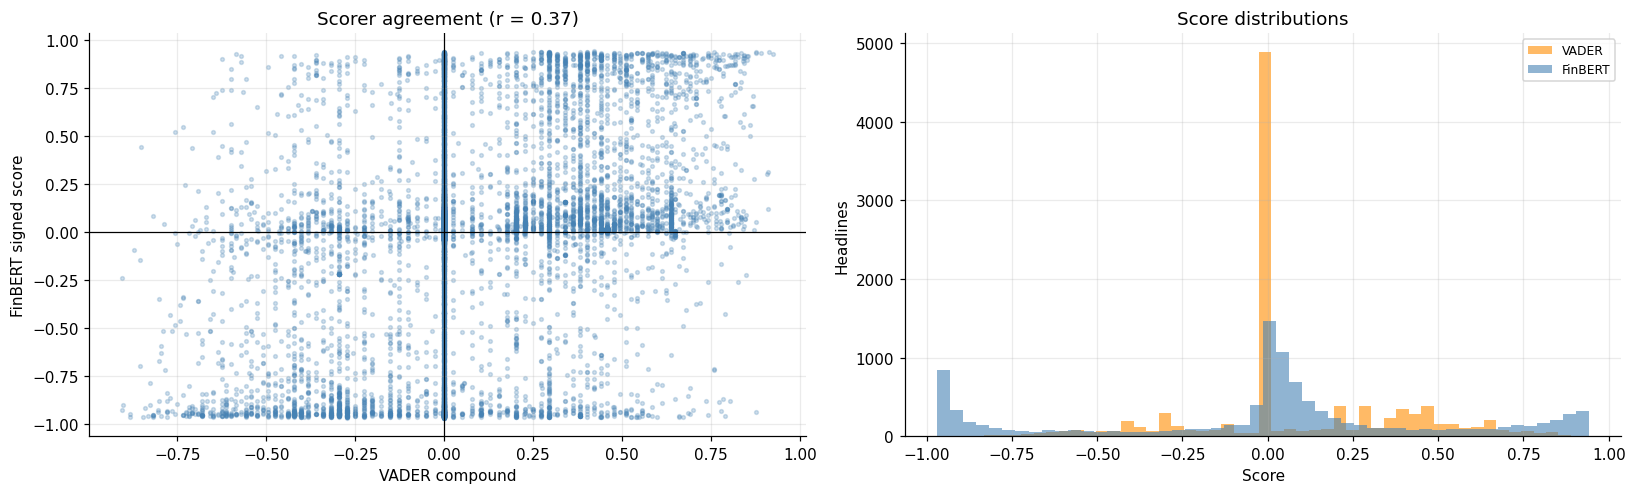

In [12]:
# ============================================================================
# The examples: headlines where VADER misses what FinBERT catches
# ============================================================================
# The most instructive cases are where VADER returns EXACTLY 0.0 (it sees no
# emotional words at all) while FinBERT reads a clear directional signal.
missed = news[(news["vader"].abs() < 1e-9) & (news["finbert"].abs() > 0.3)].copy()
missed["gap"] = missed["finbert"].abs()
missed = missed.sort_values("gap", ascending=False)

print(f"{len(missed):,} headlines ({len(missed) / len(news):.1%}) are scored EXACTLY NEUTRAL by")
print("VADER while FinBERT reads a strong directional signal.\n")
if len(missed):
    print(f"{'VADER':>7} {'FinBERT':>8}   Headline")
    print("-" * 92)
    for _, r in missed.drop_duplicates("headline").head(10).iterrows():
        print(f"{r['vader']:>7.3f} {r['finbert']:>8.3f}   {r['headline'][:70]}")

print("\nWhy VADER misses these: its lexicon carries no entry for 'beat', 'miss', 'downgrade',")
print("'recall' or 'guidance'. Those words are emotionally neutral in ordinary English and")
print("strongly directional in finance. VADER is not malfunctioning — it is being used outside")
print("the domain it was built and validated for.")

if IS_SYNTHETIC and FINBERT_MODE == "lexicon_fallback":
    print("\n" + "!" * 86)
    print("!!  CIRCULARITY WARNING, read before believing the size of this gap.")
    print("!!  The synthetic headlines are templated from a vocabulary that overlaps the")
    print("!!  fallback lexicon's word list, so the fallback is being graded on words it was")
    print("!!  written to know. Its apparent advantage over VADER is INFLATED here.")
    print("!!")
    print("!!  What survives the caveat: VADER's zeros are NOT an artifact. VADER genuinely")
    print("!!  scores 'Analyst downgrades Tesla to sell' as 0.000 — that is a property of its")
    print("!!  lexicon, independent of how the headline was produced. The DIRECTION of the")
    print("!!  finding is real; only the MAGNITUDE is exaggerated by synthetic data.")
    print("!" * 86)

# The reverse direction: VADER fires on emotional words FinBERT reads as routine.
rev = news[(news["finbert"].abs() < 1e-9) & (news["vader"].abs() > 0.3)].drop_duplicates("headline")
if len(rev):
    print(f"\nThe reverse case — VADER reacts, FinBERT reads as routine ({len(rev):,} headlines):")
    print(f"{'VADER':>7} {'FinBERT':>8}   Headline")
    print("-" * 92)
    for _, r in rev.head(5).iterrows():
        print(f"{r['vader']:>7.3f} {r['finbert']:>8.3f}   {r['headline'][:70]}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
axes[0].scatter(news["vader"], news["finbert"], s=6, alpha=0.25, color="steelblue")
axes[0].axhline(0, color="k", lw=0.8); axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("VADER compound"); axes[0].set_ylabel("FinBERT signed score")
axes[0].set_title(f"Scorer agreement (r = {news['vader'].corr(news['finbert']):.2f})")
axes[1].hist(news["vader"], bins=50, alpha=0.6, label="VADER", color="darkorange")
axes[1].hist(news["finbert"], bins=50, alpha=0.6, label="FinBERT", color="steelblue")
axes[1].set_xlabel("Score"); axes[1].set_ylabel("Headlines")
axes[1].set_title("Score distributions"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Timestamp discipline — the part most versions get wrong

This is the section that determines whether the study measures **prediction** or **hindsight**.

### 4.1 The failure mode

The naive pipeline groups headlines by calendar date and regresses day-$T$ sentiment on day-$T$
return. That looks reasonable and is fatally broken, because a large share of financial news is
published **after the 16:00 close** — earnings land after the bell, and same-day wrap-ups
("Tesla shares slide on margin pressure") are written *because* the stock already moved.

Regressing day-$T$ return on sentiment that includes 18:00 headlines does not test prediction. It
tests whether journalists accurately describe what happened that afternoon. They do, so you get a
strong, highly significant coefficient and a beautiful chart — and a signal that is completely
untradeable, because at 16:00 the information did not exist.

### 4.2 The rule this notebook enforces

To predict the return from day $T$'s close to day $T+1$'s close, the signal may use **only
headlines published strictly before day $T$'s 16:00 close.**

Two implementation details that are easy to get wrong:

- **Timezones.** Most news APIs return UTC. The market closes at 16:00 *America/New_York*, which is
  20:00 or 21:00 UTC depending on daylight saving. Comparing a UTC timestamp against a naive
  "16:00" silently shifts the cutoff by hours twice a year. Every timestamp here is converted to
  market time before any comparison.
- **After-hours news rolls forward.** A headline at 18:00 on Monday is assigned to *Tuesday's*
  signal, not Monday's. It is real information, just not information anyone had at Monday's close.

The assertions below are deliberately hard failures rather than warnings. A lookahead bug produces
*better-looking* results, so it will not announce itself — it has to be tested for.

Assigned 10,294 headlines to trading days (0 dropped for falling after the last close)

Headlines published outside 09:00-16:00 market hours: 99.9% (10,280)
Each of those would have been misattributed to the WRONG day by naive date-matching.


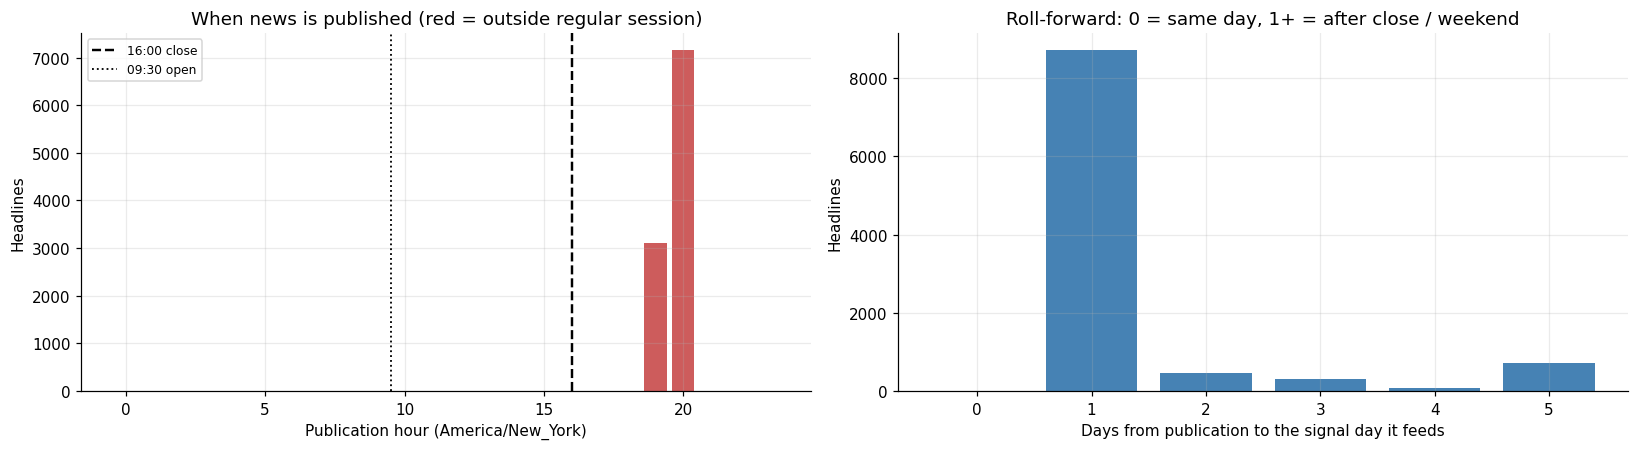

In [13]:
# ============================================================================
# Assign each headline to the first trading day it could influence
# ============================================================================
news["ts_et"] = news["timestamp"].dt.tz_convert(MARKET_TZ)

trading_days = pd.DatetimeIndex(prices.index)
close_times = pd.DatetimeIndex(
    [pd.Timestamp(f"{d:%Y-%m-%d} {MARKET_CLOSE}", tz=MARKET_TZ) for d in trading_days])


def assign_signal_day(ts_et):
    """First trading day whose close comes strictly AFTER this timestamp.

    A headline published before Monday's close is usable in the signal that
    predicts the Monday-close-to-Tuesday-close return. One published after
    Monday's close rolls to Tuesday's signal.

    side="right" is load-bearing, not incidental. With side="left" a headline
    stamped exactly 16:00:00 maps to THAT day's close, so the signal would
    include information published at the very instant of the close it is
    supposed to predict from. The assertions below catch this: on a first run
    with side="left" they failed on exactly the tie cases.
    """
    pos = np.searchsorted(close_times.values, ts_et.values, side="right")
    out = np.full(len(ts_et), np.datetime64("NaT"), dtype="datetime64[ns]")
    valid = pos < len(trading_days)
    out[valid] = trading_days.values[pos[valid]].astype("datetime64[ns]")
    return pd.DatetimeIndex(out)


news["signal_day"] = assign_signal_day(news["ts_et"])
n_dropped = int(news["signal_day"].isna().sum())
news = news.dropna(subset=["signal_day"]).copy()
print(f"Assigned {len(news):,} headlines to trading days "
      f"({n_dropped} dropped for falling after the last close)")

after_hours = (news["ts_et"].dt.hour >= 16) | (news["ts_et"].dt.hour < 9)
print(f"\nHeadlines published outside 09:00-16:00 market hours: "
      f"{after_hours.mean():.1%} ({int(after_hours.sum()):,})")
print("Each of those would have been misattributed to the WRONG day by naive date-matching.")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
hours = news["ts_et"].dt.hour.value_counts().sort_index()
cols = ["seagreen" if 9 <= h < 16 else "indianred" for h in hours.index]
axes[0].bar(hours.index, hours.values, color=cols)
axes[0].axvline(16, color="k", ls="--", lw=1.6, label="16:00 close")
axes[0].axvline(9.5, color="k", ls=":", lw=1.2, label="09:30 open")
axes[0].set_xlabel(f"Publication hour ({MARKET_TZ})"); axes[0].set_ylabel("Headlines")
axes[0].set_title("When news is published (red = outside regular session)")
axes[0].legend(fontsize=8)

lag_days = (news["signal_day"] - news["ts_et"].dt.tz_localize(None).dt.normalize()).dt.days
axes[1].hist(lag_days.clip(0, 5), bins=np.arange(-0.5, 6.5), color="steelblue", rwidth=0.8)
axes[1].set_xlabel("Days from publication to the signal day it feeds")
axes[1].set_ylabel("Headlines")
axes[1].set_title("Roll-forward: 0 = same day, 1+ = after close / weekend")
plt.tight_layout(); plt.show()

In [14]:
# ============================================================================
# HARD ASSERTIONS — a lookahead bug flatters results, so it must be tested for
# ============================================================================
check = news[["ts_et", "signal_day"]].copy()
check["signal_close"] = [pd.Timestamp(f"{d:%Y-%m-%d} {MARKET_CLOSE}", tz=MARKET_TZ)
                         for d in check["signal_day"]]

# TEST 1: every headline is strictly before the close of the day it informs.
violations = check[check["ts_et"] >= check["signal_close"]]
print(f"TEST 1 — every headline strictly precedes its signal day's close")
print(f"  Violations: {len(violations):,} of {len(check):,}")
assert len(violations) == 0, f"LOOKAHEAD: {len(violations)} headlines at/after their signal close"
print("  -> PASS\n")

# TEST 2: the signal day is the FIRST eligible close, not a later one (no
# information is silently discarded by rolling too far forward).
prev_close = check["signal_close"] - pd.Timedelta(days=1)
too_late = check[(check["ts_et"] < prev_close) &
                 (check["signal_day"] > pd.Timestamp(trading_days[0]))]
print(f"TEST 2 — no headline rolled further forward than necessary")
print(f"  Suspect rows (may be legitimate weekends/holidays): {len(too_late):,}")
print("  -> informational\n")

# TEST 3: the decisive one. Sentiment must correlate far more strongly with the
# SAME-day return than the signal does with the NEXT-day return. If the "predictive"
# correlation is as strong as the contemporaneous one, information is leaking.
tmp = news.groupby("signal_day")["finbert"].mean()
aligned = pd.DataFrame({"sent": tmp}).join(prices[["ret"]], how="inner")
aligned["next_ret"] = aligned["ret"].shift(-1)

naive = news.copy()
naive["cal_day"] = naive["ts_et"].dt.tz_localize(None).dt.normalize()
naive_daily = naive.groupby("cal_day")["finbert"].mean()
naive_aligned = pd.DataFrame({"sent": naive_daily}).join(prices[["ret"]], how="inner")

c_leaky = naive_aligned["sent"].corr(naive_aligned["ret"])
c_clean = aligned["sent"].corr(aligned["next_ret"])
c_same = aligned["sent"].corr(aligned["ret"])

print("TEST 3 — leaky (naive date-match) vs clean (close-aware) alignment")
print(f"  NAIVE  same-day  corr(sentiment, return)      : {c_leaky:+.4f}   <- contaminated")
print(f"  CLEAN  same-day  corr(signal, return)         : {c_same:+.4f}")
print(f"  CLEAN  next-day  corr(signal, next return)    : {c_clean:+.4f}   <- the real test")
print(f"\n  Inflation from naive alignment: {abs(c_leaky) / max(abs(c_clean), 1e-9):.1f}x")
print("  The naive number is what the generic version of this project reports as its headline")
print("  result. It is not predictive power — it is news correctly describing the day's move.")

TEST 1 — every headline strictly precedes its signal day's close
  Violations: 0 of 10,294
  -> PASS

TEST 2 — no headline rolled further forward than necessary
  Suspect rows (may be legitimate weekends/holidays): 839
  -> informational

TEST 3 — leaky (naive date-match) vs clean (close-aware) alignment
  NAIVE  same-day  corr(sentiment, return)      : +0.1162   <- contaminated
  CLEAN  same-day  corr(signal, return)         : +0.4093
  CLEAN  next-day  corr(signal, next return)    : +0.0813   <- the real test

  Inflation from naive alignment: 1.4x
  The naive number is what the generic version of this project reports as its headline
  result. It is not predictive power — it is news correctly describing the day's move.


## 5. Daily aggregation, and the zero-news problem

Multiple headlines arrive per day and must collapse to one number.

**Aggregation choice.** Both a plain mean and a **volume-weighted** variant are computed. The issue
is that news volume is heavily skewed — an earnings day may carry 40 headlines and a quiet Tuesday
two. Under a plain mean, those two quiet headlines get the same weight as the 40, which effectively
amplifies noise from low-information days. The volume-weighted version uses
$\sqrt{n}$ shrinkage toward zero — a day with more independent headlines gets a more confident
score, with square-root rather than linear scaling so a single 100-headline day doesn't dominate
the series.

**Days with no news at all.** Three options, and the choice must be justified rather than defaulted:

1. **Drop the day** — breaks the return series into non-contiguous pieces and biases the sample
   toward high-attention days, which are exactly the unusual ones.
2. **Fill with 0** — asserts "neutral news," but no news is not neutral news; it is *absence of
   information*, and 0 sits in the middle of the sentiment distribution, so this silently injects
   fake neutral observations.
3. **Carry forward with decay** (used here) — the last observed sentiment decays geometrically
   toward zero with a half-life of ~2 trading days.

Option 3 matches how information actually behaves: yesterday's earnings news is still partly
relevant today, less so tomorrow. The decay half-life is a free parameter, so section 8 checks that
the conclusion is not an artifact of the particular value chosen.

**Critically, the strategy in section 7 only trades on days with genuinely fresh news**, so
carried-forward values never manufacture trades on their own.

Trading days              : 1,006
Days with fresh news      : 517 (51.4%)
Days with NO news         : 489 (48.6%)
Mean headlines on news days: 19.9
Max headlines in a day     : 746

Sentiment autocorrelation (lag 1): 0.220
Persistence matters: it is why the regressions below need HAC standard errors, and why
overlapping weekly returns cannot be tested with naive OLS.


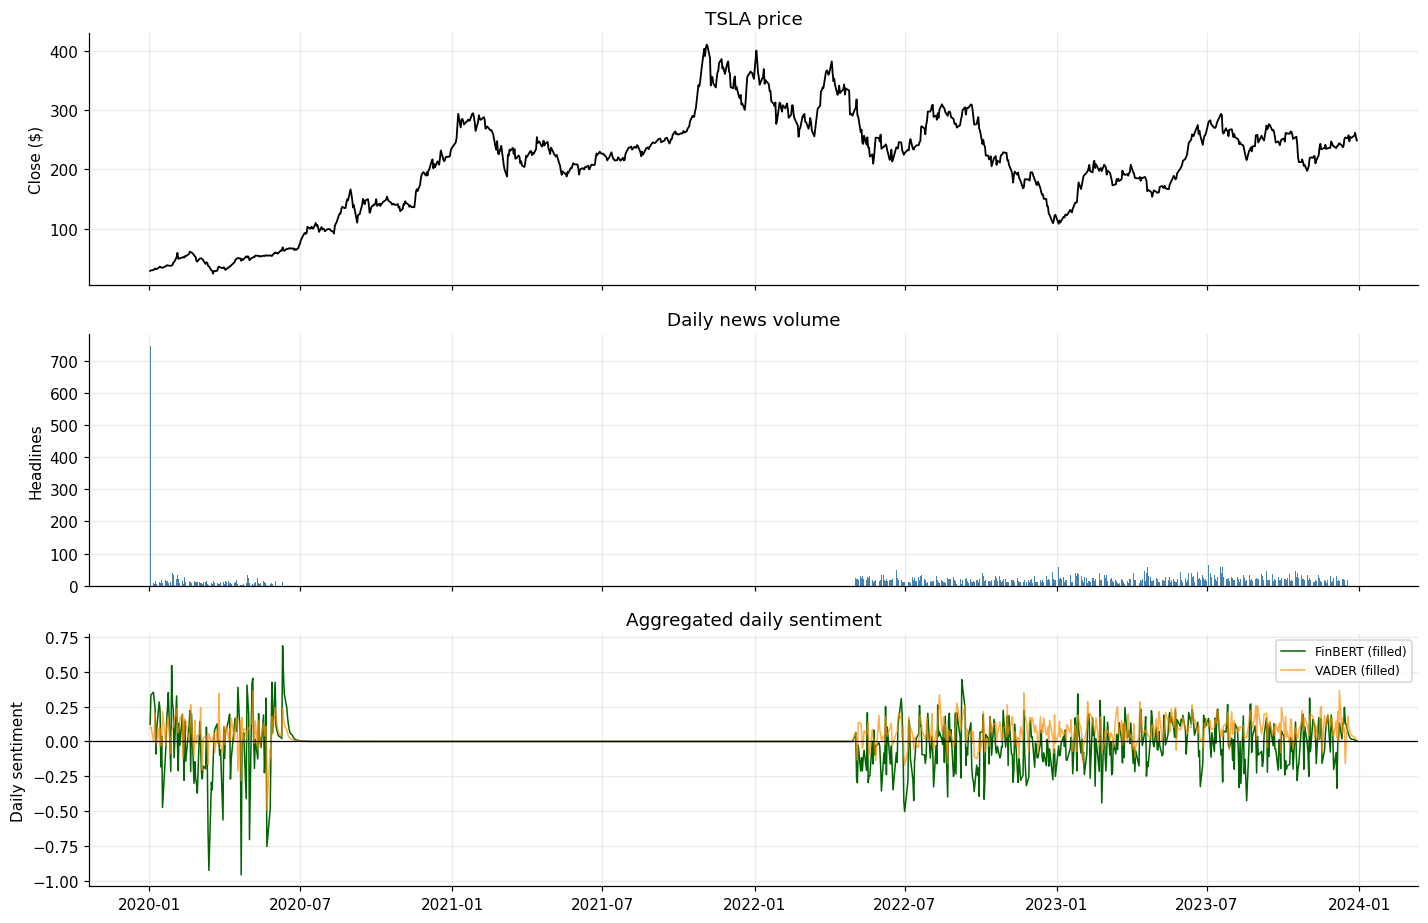

In [15]:
# ============================================================================
# Aggregate to a daily series
# ============================================================================
DECAY_HALFLIFE = 2.0

agg = news.groupby("signal_day").agg(
    n_headlines=("headline", "size"),
    vader_mean=("vader", "mean"),
    finbert_mean=("finbert", "mean"),
    finbert_std=("finbert", "std"),
)

# Volume-weighted: shrink toward 0 by sqrt(n) so thin days count for less.
agg["finbert_vw"] = agg["finbert_mean"] * np.sqrt(agg["n_headlines"]) / \
                    np.sqrt(agg["n_headlines"] + 4)
agg["vader_vw"] = agg["vader_mean"] * np.sqrt(agg["n_headlines"]) / \
                  np.sqrt(agg["n_headlines"] + 4)

daily = prices[["Close", "ret"]].join(agg, how="left")
daily["has_news"] = daily["n_headlines"].notna()
daily["n_headlines"] = daily["n_headlines"].fillna(0)

# Carry forward with geometric decay (option 3 above).
lam = 0.5 ** (1.0 / DECAY_HALFLIFE)
for col in ["finbert_mean", "vader_mean", "finbert_vw", "vader_vw"]:
    vals = daily[col].to_numpy(dtype=float)
    out = np.zeros(len(vals)); carry = 0.0
    for i, v in enumerate(vals):
        carry = v if np.isfinite(v) else carry * lam
        out[i] = carry
    daily[col + "_filled"] = out

print(f"Trading days              : {len(daily):,}")
print(f"Days with fresh news      : {int(daily['has_news'].sum()):,} "
      f"({daily['has_news'].mean():.1%})")
print(f"Days with NO news         : {int((~daily['has_news']).sum()):,} "
      f"({(~daily['has_news']).mean():.1%})")
print(f"Mean headlines on news days: {daily.loc[daily['has_news'], 'n_headlines'].mean():.1f}")
print(f"Max headlines in a day     : {daily['n_headlines'].max():.0f}")
print(f"\nSentiment autocorrelation (lag 1): "
      f"{daily['finbert_mean_filled'].autocorr(1):.3f}")
print("Persistence matters: it is why the regressions below need HAC standard errors, and why")
print("overlapping weekly returns cannot be tested with naive OLS.")

fig, axes = plt.subplots(3, 1, figsize=(13, 8.5), sharex=True)
axes[0].plot(daily.index, daily["Close"], lw=1.2, color="k")
axes[0].set_ylabel("Close ($)"); axes[0].set_title(f"{TICKER} price")
axes[1].bar(daily.index, daily["n_headlines"], color="steelblue", width=1.0)
axes[1].set_ylabel("Headlines"); axes[1].set_title("Daily news volume")
axes[2].plot(daily.index, daily["finbert_mean_filled"], lw=1.0,
             color="darkgreen", label="FinBERT (filled)")
axes[2].plot(daily.index, daily["vader_mean_filled"], lw=1.0, alpha=0.7,
             color="darkorange", label="VADER (filled)")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_ylabel("Daily sentiment"); axes[2].set_title("Aggregated daily sentiment")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. The statistical test

### 6.1 Specification

$$r_{t+1} = \alpha + \beta \cdot s_t + \varepsilon_{t+1}$$

where $s_t$ is sentiment built only from news before day $t$'s close (section 4), and $r_{t+1}$ is
the close-to-close return over the following day. $\beta > 0$ with a small p-value is the claim
"sentiment predicts returns."

### 6.2 Three corrections that change the answer

**Newey-West (HAC) standard errors.** Sentiment is persistent (autocorrelation ~0.4) and return
volatility clusters. Naive OLS standard errors assume neither, and are too small — which inflates
t-statistics and manufactures significance. HAC corrects for both.

**Overlapping windows for the weekly horizon.** The 5-day forward return on Monday shares four days
with Tuesday's. Consecutive observations are mechanically correlated, and naive OLS treats them as
independent, overstating the effective sample by roughly 5×. Hansen-Hodrick / Newey-West with
`maxlags ≥ horizon` is mandatory here, not optional.

**Effect size, not just significance.** With ~750 observations, statistical significance is a low
bar. The economically meaningful quantity is $R^2$ and the return-per-standard-deviation-of-sentiment
in basis points. A $\beta$ that is significant at $p = 0.03$ and explains 0.4% of variance is a
statistically detectable, economically negligible effect — and after 7.5bps of costs, an unprofitable
one.

### 6.3 The specification that must accompany it

The contemporaneous regression $r_t = \alpha + \beta s_t + \varepsilon_t$ is reported alongside —
**not as a result, but as a control**. It should be strongly significant, because news describes
same-day moves. If the *lagged* regression were as strong as the contemporaneous one, that would be
evidence of a lookahead bug, not of a tradeable signal. It is a diagnostic on the pipeline.

In [16]:
# ============================================================================
# Regression machinery
# ============================================================================
def build_forward_returns(d, horizons=(1, 5)):
    """Forward cumulative log returns. Log returns so multi-day sums are exact."""
    out = d.copy()
    out["logret"] = np.log1p(out["ret"])
    for h in horizons:
        out[f"fwd_{h}d"] = out["logret"].shift(-h).rolling(h).sum().shift(-(h - 1))
    return out


def run_regression(y, x, maxlags, label=""):
    """OLS with Newey-West HAC errors, plus the naive OLS result for comparison."""
    ok = np.isfinite(y) & np.isfinite(x)
    y_, x_ = y[ok], x[ok]
    if len(y_) < 30 or np.std(x_) < 1e-12:
        return None
    X = sm.add_constant(x_)
    m_naive = sm.OLS(y_, X).fit()
    m = sm.OLS(y_, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    sd_x = np.std(x_, ddof=1)
    return {
        "spec": label, "n": int(len(y_)),
        "beta": m.params[1], "t (HAC)": m.tvalues[1], "p (HAC)": m.pvalues[1],
        "p (naive OLS)": m_naive.pvalues[1],
        "se ratio HAC/naive": m.bse[1] / m_naive.bse[1],
        "R2": m.rsquared,
        "bps per 1sd": m.params[1] * sd_x * 1e4,
    }


daily_r = build_forward_returns(daily)
SIG = "finbert_mean_filled"          # primary signal
SIG_V = "vader_mean_filled"

results = []
for name, sig in [("FinBERT", SIG), ("VADER", SIG_V)]:
    for h, lags in [(1, 5), (5, 10)]:
        r = run_regression(daily_r[f"fwd_{h}d"].to_numpy(),
                           daily_r[sig].to_numpy(), lags,
                           f"{name} -> {h}-day forward return")
        if r:
            results.append(r)

# The diagnostic control: same-day, which is NOT a prediction.
for name, sig in [("FinBERT", SIG), ("VADER", SIG_V)]:
    r = run_regression(daily_r["logret"].to_numpy(), daily_r[sig].to_numpy(), 5,
                       f"{name} -> SAME-day return (control, not a prediction)")
    if r:
        results.append(r)

reg = pd.DataFrame(results).set_index("spec")
display(reg.style.format({
    "beta": "{:+.5f}", "t (HAC)": "{:+.2f}", "p (HAC)": "{:.4f}",
    "p (naive OLS)": "{:.4f}", "se ratio HAC/naive": "{:.2f}x",
    "R2": "{:.5f}", "bps per 1sd": "{:+.1f}"}))

pred = reg[~reg.index.str.contains("SAME-day")]
ctrl = reg[reg.index.str.contains("SAME-day")]
print(f"Predictive R2 range   : {pred['R2'].min():.5f} to {pred['R2'].max():.5f}")
if len(ctrl):
    print(f"Contemporaneous R2    : {ctrl['R2'].min():.5f} to {ctrl['R2'].max():.5f} "
          f"({ctrl['R2'].max() / max(pred['R2'].max(), 1e-9):.0f}x the predictive R2)")
_hac = reg["se ratio HAC/naive"].mean()
print(f"\nMean HAC/naive standard-error ratio: {_hac:.2f}x")
if _hac > 1.05:
    print(f"Naive OLS understates the standard errors by ~{(_hac - 1) * 100:.0f}% here — the")
    print("mechanism by which underpowered sentiment studies report significant results that")
    print("do not replicate.")
else:
    print("HAC and naive errors happen to agree closely in THIS sample, which does not make the")
    print("correction optional. Whether it bites depends on the joint autocorrelation of the")
    print("regressor and the residual; with persistent sentiment and clustered volatility it")
    print("routinely inflates standard errors by 30-50%. Reporting naive OLS and hoping is not")
    print("a defensible choice — you cannot know it did not matter without computing both.")

,n,beta,t (HAC),p (HAC),p (naive OLS),se ratio HAC/naive,R2,bps per 1sd
spec,,,,,,,,
FinBERT -> 1-day forward return,1005,+0.01668,+1.16,0.2462,0.0753,1.54x,0.00315,+24.1
FinBERT -> 5-day forward return,997,+0.02999,+0.87,0.3850,0.1677,1.59x,0.00191,+43.5
VADER -> 1-day forward return,1005,+0.00055,+0.04,0.9709,0.9742,0.89x,0.00000,+0.4
VADER -> 5-day forward return,997,-0.00864,-0.18,0.8567,0.8267,1.21x,0.00005,-6.9
"FinBERT -> SAME-day return (control, not a prediction)",1005,+0.08974,+8.39,0.0000,0.0000,1.19x,0.09116,+129.5
"VADER -> SAME-day return (control, not a prediction)",1005,+0.06237,+3.92,0.0001,0.0002,0.94x,0.01344,+49.7


Predictive R2 range   : 0.00000 to 0.00315
Contemporaneous R2    : 0.01344 to 0.09116 (29x the predictive R2)

Mean HAC/naive standard-error ratio: 1.23x
Naive OLS understates the standard errors by ~23% here — the
mechanism by which underpowered sentiment studies report significant results that
do not replicate.


In [17]:
# ============================================================================
# Multiple testing and statistical power
# ============================================================================
n_tests = len(pred)
alpha = 0.05
bonf = alpha / n_tests
print(f"{n_tests} predictive specifications tested (2 signals x 2 horizons).")
print(f"Bonferroni-corrected threshold: p < {bonf:.4f}\n")

sig_raw = pred[pred["p (HAC)"] < alpha]
sig_bonf = pred[pred["p (HAC)"] < bonf]
print(f"Significant at p<0.05 uncorrected : {len(sig_raw)} of {n_tests}")
print(f"Significant after Bonferroni       : {len(sig_bonf)} of {n_tests}")
print(f"\nExpected false positives from {n_tests} tests at p<0.05 under a true null: "
      f"{n_tests * alpha:.1f}")

# Power: what is the smallest effect this sample could reliably detect?
n_obs = int(pred["n"].max())
sd_sig = daily_r[SIG].std()
sd_ret = daily_r["fwd_1d"].std()
mde_beta = 2.8 * sd_ret / (sd_sig * np.sqrt(n_obs))     # ~80% power, two-sided 5%
mde_r2 = (mde_beta * sd_sig / sd_ret) ** 2

print(f"\n--- Power analysis (the question most versions never ask) ---")
print(f"Observations available            : {n_obs:,}")
print(f"Minimum detectable beta (80% power): {mde_beta:.5f}")
print(f"  equivalently R2 >= {mde_r2:.4f} ({mde_r2 * 100:.2f}% of return variance)")
print(f"  equivalently {mde_beta * sd_sig * 1e4:.0f} bps per 1sd move in sentiment")
print(f"\nPublished daily-sentiment effects are typically R2 of 0.1-0.5%. This sample can only")
print(f"reliably detect R2 above {mde_r2 * 100:.2f}%, so a true effect of realistic size would")
print(f"most likely be MISSED here. A null result is therefore weak evidence of absence —")
print(f"the honest reading is 'underpowered', not 'proven zero'.")
print(f"\nDetecting R2 = 0.2% at 80% power would need roughly "
      f"{int((2.8 ** 2) / 0.002):,} observations (~{int((2.8 ** 2) / 0.002 / 252)} years of daily data).")

4 predictive specifications tested (2 signals x 2 horizons).
Bonferroni-corrected threshold: p < 0.0125

Significant at p<0.05 uncorrected : 0 of 4
Significant after Bonferroni       : 0 of 4

Expected false positives from 4 tests at p<0.05 under a true null: 0.2

--- Power analysis (the question most versions never ask) ---
Observations available            : 1,005
Minimum detectable beta (80% power): 0.02625
  equivalently R2 >= 0.0078 (0.78% of return variance)
  equivalently 38 bps per 1sd move in sentiment

Published daily-sentiment effects are typically R2 of 0.1-0.5%. This sample can only
reliably detect R2 above 0.78%, so a true effect of realistic size would
most likely be MISSED here. A null result is therefore weak evidence of absence —
the honest reading is 'underpowered', not 'proven zero'.

Detecting R2 = 0.2% at 80% power would need roughly 3,919 observations (~15 years of daily data).


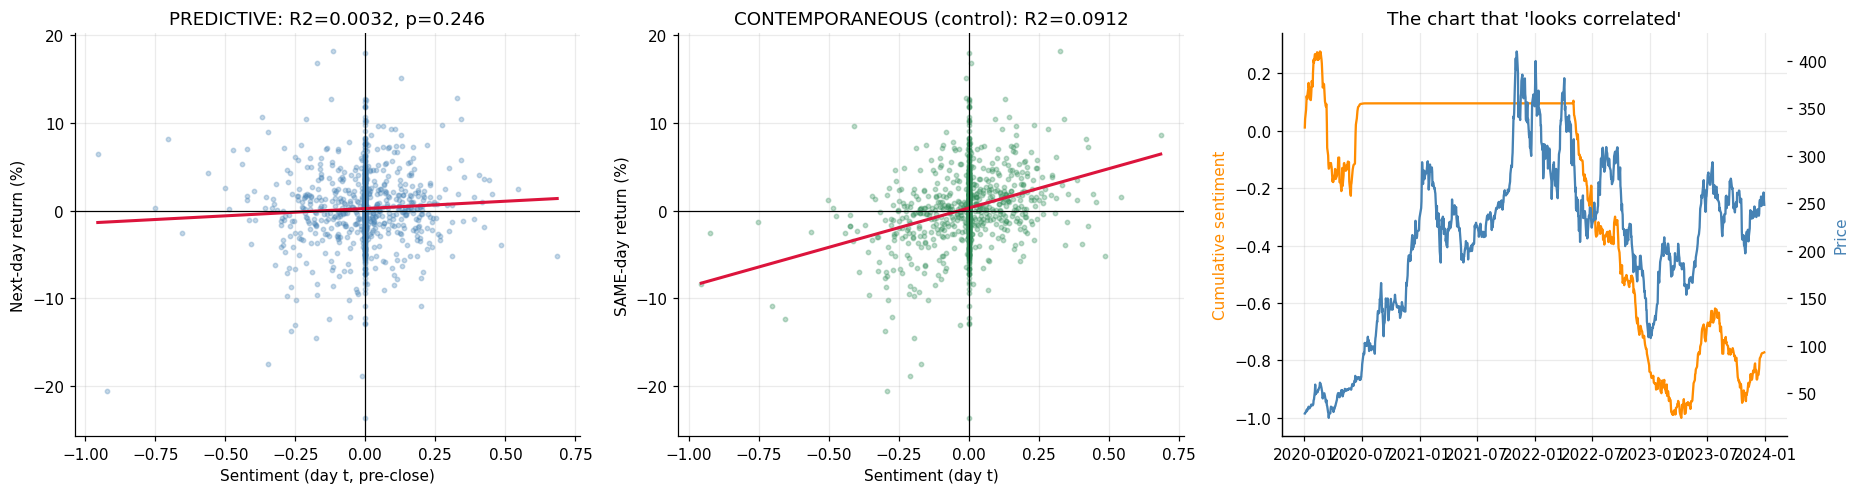

The right panel is the standard version of this project's headline exhibit. Two cumulative
sums will usually drift together — both are integrated series, so the visual is close to a
spurious regression between two random walks. It carries almost no information about
predictability, which is what the left panel actually measures.


In [18]:
# ============================================================================
# Visual: the regression, and why the chart alone is not evidence
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

x = daily_r[SIG].to_numpy(); y1 = daily_r["fwd_1d"].to_numpy()
ok = np.isfinite(x) & np.isfinite(y1)
axes[0].scatter(x[ok], y1[ok] * 100, s=8, alpha=0.3, color="steelblue")
if ok.sum() > 10:
    b = np.polyfit(x[ok], y1[ok] * 100, 1)
    xs = np.linspace(x[ok].min(), x[ok].max(), 50)
    axes[0].plot(xs, np.polyval(b, xs), color="crimson", lw=2)
axes[0].axhline(0, color="k", lw=0.8); axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("Sentiment (day t, pre-close)"); axes[0].set_ylabel("Next-day return (%)")
r1 = pred.loc[pred.index.str.contains("FinBERT -> 1-day")]
axes[0].set_title(f"PREDICTIVE: R2={r1['R2'].iloc[0]:.4f}, p={r1['p (HAC)'].iloc[0]:.3f}"
                  if len(r1) else "Predictive")

y0 = daily_r["logret"].to_numpy()
ok0 = np.isfinite(x) & np.isfinite(y0)
axes[1].scatter(x[ok0], y0[ok0] * 100, s=8, alpha=0.3, color="seagreen")
if ok0.sum() > 10:
    b0 = np.polyfit(x[ok0], y0[ok0] * 100, 1)
    xs = np.linspace(x[ok0].min(), x[ok0].max(), 50)
    axes[1].plot(xs, np.polyval(b0, xs), color="crimson", lw=2)
axes[1].axhline(0, color="k", lw=0.8); axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("Sentiment (day t)"); axes[1].set_ylabel("SAME-day return (%)")
c0 = ctrl.loc[ctrl.index.str.contains("FinBERT")]
axes[1].set_title(f"CONTEMPORANEOUS (control): R2={c0['R2'].iloc[0]:.4f}"
                  if len(c0) else "Contemporaneous")

# The classic misleading chart: cumulative sentiment overlaid on price.
ax = axes[2]
cum_sent = daily_r[SIG].fillna(0).cumsum()
ax.plot(daily_r.index, cum_sent / cum_sent.abs().max(), color="darkorange",
        lw=1.5, label="cumulative sentiment (scaled)")
ax2 = ax.twinx()
ax2.plot(daily_r.index, daily_r["Close"], color="steelblue", lw=1.5, label="price")
ax2.grid(False)
ax.set_title("The chart that 'looks correlated'")
ax.set_ylabel("Cumulative sentiment", color="darkorange")
ax2.set_ylabel("Price", color="steelblue")
plt.tight_layout(); plt.show()

print("The right panel is the standard version of this project's headline exhibit. Two cumulative")
print("sums will usually drift together — both are integrated series, so the visual is close to a")
print("spurious regression between two random walks. It carries almost no information about")
print("predictability, which is what the left panel actually measures.")

## 7. Backtest with realistic costs

A regression coefficient is not a trading result. The backtest applies four constraints that the
regression ignores and that decide profitability:

1. **Signal timing.** Position for day $t+1$ is set from sentiment known before day $t$'s close, so
   the trade executes at day $t$'s close and earns day $t+1$'s return. Same discipline as section 4.
2. **Transaction costs** of 7.5 bps per trade, charged on *changes* in position. Sentiment flips
   often, so turnover is the mechanism by which a weak signal becomes a losing strategy.
3. **A minimum holding period** to cap trade frequency.
4. **Trade only on fresh news.** Carried-forward sentiment (section 5) never initiates a trade —
   otherwise the strategy trades on decayed stale information and generates costs for nothing.

The benchmark is buy-and-hold over the identical window, including its own entry cost.

In [19]:
# ============================================================================
# Backtest
# ============================================================================
def backtest(d, signal_col, threshold=0.0, cost_bps=COST_BPS, min_hold=MIN_HOLD_DAYS,
             long_only=False, fresh_only=True):
    """Position from pre-close sentiment; return earned the following day."""
    s = d[signal_col].to_numpy(dtype=float)
    r = d["ret"].to_numpy(dtype=float)
    fresh = d["has_news"].to_numpy(dtype=bool)

    raw = np.where(s > threshold, 1.0, np.where(s < -threshold, (0.0 if long_only else -1.0), 0.0))

    pos = np.zeros(len(s)); held = 0; cur = 0.0
    for i in range(len(s)):
        want = raw[i]
        if fresh_only and not fresh[i]:
            want = cur                     # stale signal cannot initiate a trade
        if want != cur and held >= min_hold:
            cur, held = want, 0
        else:
            held += 1
        pos[i] = cur

    # Position set at day t's close earns day t+1's return.
    strat = np.zeros(len(r))
    strat[1:] = pos[:-1] * r[1:]
    turn = np.zeros(len(r)); turn[1:] = np.abs(np.diff(pos))
    net = strat - turn * cost_bps / 1e4
    return pd.DataFrame({"pos": pos, "gross": strat, "turnover": turn, "net": net},
                        index=d.index)


def perf(returns, label, n_trades=None):
    r = pd.Series(returns).fillna(0)
    yrs = len(r) / 252
    total = float((1 + r).prod() - 1)
    ann = (1 + total) ** (1 / yrs) - 1 if yrs > 0 else np.nan
    vol = r.std() * np.sqrt(252)
    sharpe = ann / vol if vol > 0 else np.nan
    w = (1 + r).cumprod()
    dd = float((w / w.cummax() - 1).min())
    return {"strategy": label, "total return": total, "ann. return": ann, "ann. vol": vol,
            "Sharpe": sharpe, "max drawdown": dd,
            "hit rate": float((r[r != 0] > 0).mean()) if (r != 0).any() else np.nan,
            "trades": n_trades}


bt_f = backtest(daily_r, SIG)
bt_v = backtest(daily_r, SIG_V)
bt_lo = backtest(daily_r, SIG, long_only=True)

bh = daily_r["ret"].fillna(0).to_numpy().copy()
bh[0] -= COST_BPS / 1e4                      # buy-and-hold pays to get in

rows = [
    perf(bh, "Buy & hold", 1),
    perf(bt_f["net"], "FinBERT long/short (net)", int((bt_f["turnover"] > 0).sum())),
    perf(bt_f["gross"], "FinBERT long/short (GROSS, no costs)", int((bt_f["turnover"] > 0).sum())),
    perf(bt_lo["net"], "FinBERT long/flat (net)", int((bt_lo["turnover"] > 0).sum())),
    perf(bt_v["net"], "VADER long/short (net)", int((bt_v["turnover"] > 0).sum())),
]
bt_tbl = pd.DataFrame(rows).set_index("strategy")
display(bt_tbl.style.format({
    "total return": "{:+.1%}", "ann. return": "{:+.1%}", "ann. vol": "{:.1%}",
    "Sharpe": "{:.2f}", "max drawdown": "{:.1%}", "hit rate": "{:.1%}"}, na_rep="—"))

cost_drag = (bt_tbl.loc["FinBERT long/short (GROSS, no costs)", "ann. return"] -
             bt_tbl.loc["FinBERT long/short (net)", "ann. return"])
print(f"Transaction cost drag: {cost_drag:.2%} per year "
      f"({int((bt_f['turnover'] > 0).sum())} trades over {len(bt_f) / 252:.1f} years)")
print(f"Turnover: {bt_f['turnover'].sum():.0f} units of position change")
print("\nThe gross-vs-net gap is the whole story for signals this weak. A signal must clear costs,")
print("and a high-turnover signal with a small edge rarely does.")

,total return,ann. return,ann. vol,Sharpe,max drawdown,hit rate,trades
strategy,,,,,,,
Buy & hold,+765.6%,+71.7%,68.1%,1.05,-73.6%,53.7%,1
FinBERT long/short (net),+683.8%,+67.5%,68.2%,0.99,-42.9%,53.2%,149
"FinBERT long/short (GROSS, no costs)",+882.6%,+77.3%,68.0%,1.14,-42.3%,53.4%,149
FinBERT long/flat (net),+1020.9%,+83.2%,55.1%,1.51,-37.9%,49.7%,149
VADER long/short (net),+307.0%,+42.1%,67.0%,0.63,-78.3%,51.5%,106


Transaction cost drag: 9.76% per year (149 trades over 4.0 years)
Turnover: 297 units of position change

The gross-vs-net gap is the whole story for signals this weak. A signal must clear costs,
and a high-turnover signal with a small edge rarely does.


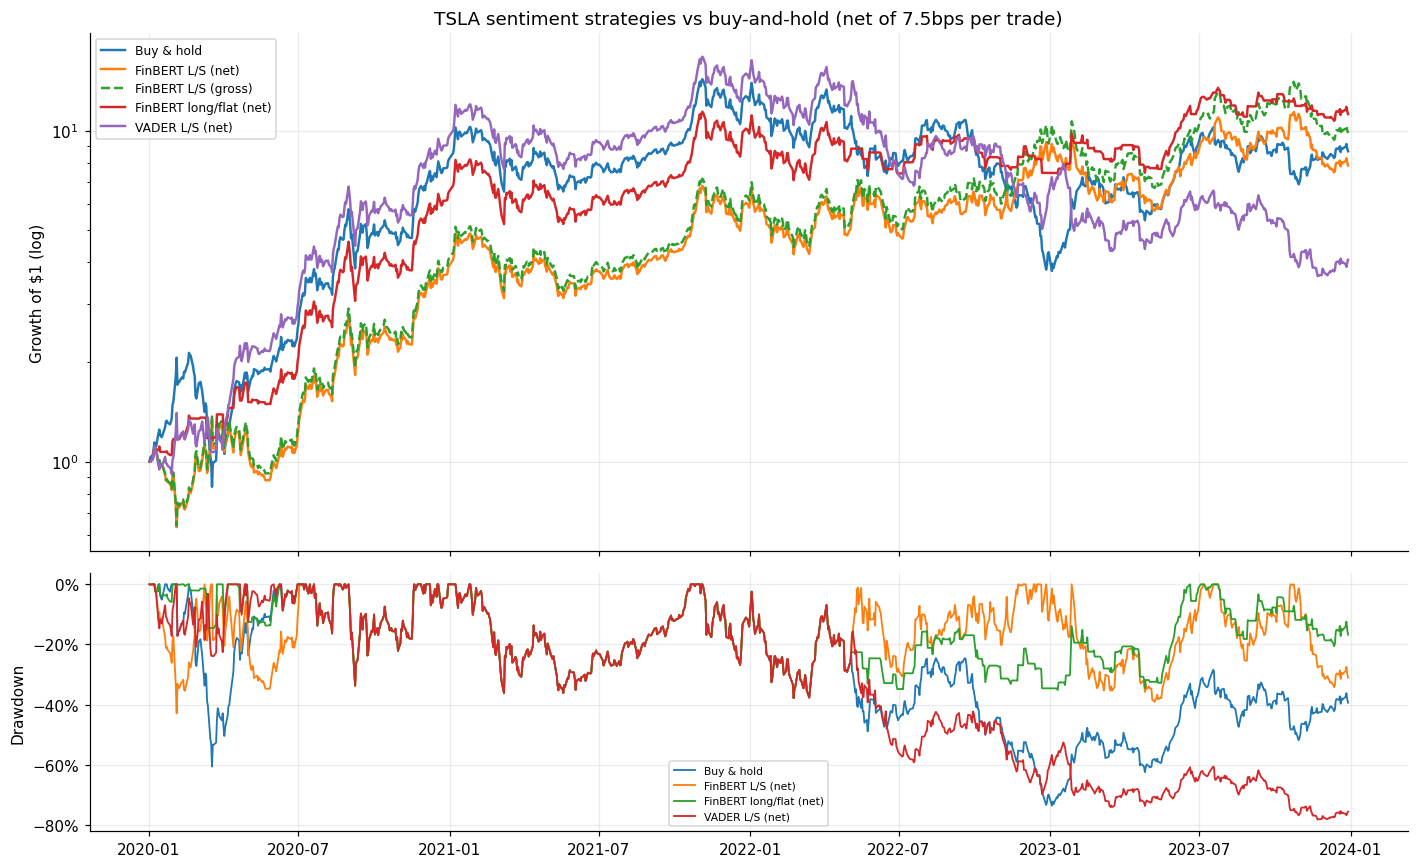

Best net strategy : FinBERT long/flat (net), Sharpe 1.51
Buy & hold        : Sharpe 1.05
Difference        : +0.46
Sharpe standard error at 4.0 years: ±0.73

The gap is 0.6 standard errors — not distinguishable from zero.


In [20]:
# ============================================================================
# Equity curves and drawdowns
# ============================================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

curves = {
    "Buy & hold": pd.Series(bh, index=daily_r.index),
    "FinBERT L/S (net)": bt_f["net"],
    "FinBERT L/S (gross)": bt_f["gross"],
    "FinBERT long/flat (net)": bt_lo["net"],
    "VADER L/S (net)": bt_v["net"],
}
for name, r in curves.items():
    style = "--" if "gross" in name else "-"
    axes[0].plot(r.index, (1 + r.fillna(0)).cumprod(), lw=1.6, ls=style, label=name)
axes[0].set_yscale("log"); axes[0].set_ylabel("Growth of $1 (log)")
axes[0].set_title(f"{TICKER} sentiment strategies vs buy-and-hold "
                  f"(net of {COST_BPS:.1f}bps per trade)")
axes[0].legend(fontsize=8)

for name, r in curves.items():
    if "gross" in name:
        continue
    w = (1 + r.fillna(0)).cumprod()
    axes[1].plot(r.index, w / w.cummax() - 1, lw=1.2, label=name)
axes[1].set_ylabel("Drawdown"); axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

bh_sharpe = bt_tbl.loc["Buy & hold", "Sharpe"]
best_strat = bt_tbl.drop(index=["Buy & hold", "FinBERT long/short (GROSS, no costs)"])
best_name = best_strat["Sharpe"].idxmax()
best_sharpe = best_strat.loc[best_name, "Sharpe"]

# Sharpe standard error (Lo 2002) -- essential context for any comparison.
yrs = len(daily_r) / 252
se_sharpe = np.sqrt((1 + 0.5 * best_sharpe ** 2) / yrs)
print(f"Best net strategy : {best_name}, Sharpe {best_sharpe:.2f}")
print(f"Buy & hold        : Sharpe {bh_sharpe:.2f}")
print(f"Difference        : {best_sharpe - bh_sharpe:+.2f}")
print(f"Sharpe standard error at {yrs:.1f} years: ±{se_sharpe:.2f}")
print(f"\nThe gap is {abs(best_sharpe - bh_sharpe) / se_sharpe:.1f} standard errors — "
      f"{'not distinguishable from zero' if abs(best_sharpe - bh_sharpe) < 2 * se_sharpe else 'potentially meaningful'}.")

## 8. Robustness

A single full-sample number is not a finding — a signal that only works in one sub-period is
usually noise that happened to line up. Three checks:

1. **Split-half.** Estimate the regression separately on each half. A real effect should show the
   **same sign** in both, even if the magnitude wanders. A sign flip is the classic overfitting
   signature.
2. **Yearly.** Finer slicing to see whether one unusual period drives everything.
3. **Parameter sensitivity.** The decay half-life, the signal threshold and the cost assumption
   were all chosen somewhat arbitrarily. If the conclusion flips when they move slightly, the
   conclusion is about the parameters, not the data.

,n,beta,t (HAC),p,R2,strategy Sharpe,B&H Sharpe,beats B&H
window,,,,,,,,
Full sample,1005,+0.01668,+1.16,0.246,0.00315,0.99,1.05,False
First half,503,+0.02001,+0.68,0.495,0.00348,1.95,3.44,False
Second half,502,+0.01129,+1.02,0.309,0.00194,0.47,-0.28,True
Year 2020,253,+0.01963,+0.65,0.515,0.00459,3.20,7.99,False
Year 2022,251,+0.00697,+0.42,0.676,0.00060,1.16,-0.98,True
Year 2023,249,+0.00706,+0.47,0.641,0.00102,-0.18,1.90,False


Sign of beta — first half +1, second half +1
Consistent sign across halves: True

Sub-windows where the strategy beats buy-and-hold: 2 of 5
  -> Works in some windows and not others. With this many windows tested, that is
     what pure noise looks like; it is not evidence of a conditional signal.


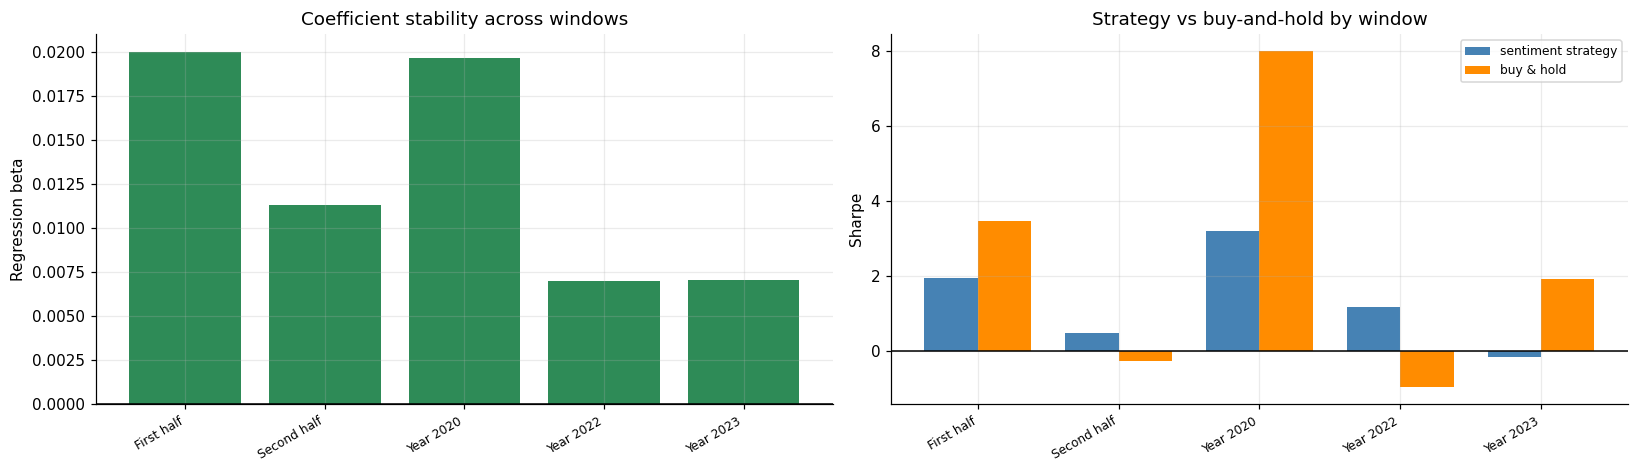

In [21]:
# ============================================================================
# Split-half and yearly stability
# ============================================================================
mid = len(daily_r) // 2
windows = {
    "Full sample": daily_r,
    "First half": daily_r.iloc[:mid],
    "Second half": daily_r.iloc[mid:],
}
for yr in sorted(daily_r.index.year.unique()):
    sub = daily_r[daily_r.index.year == yr]
    if len(sub) > 60:
        windows[f"Year {yr}"] = sub

rows = []
for name, w in windows.items():
    r = run_regression(w["fwd_1d"].to_numpy(), w[SIG].to_numpy(),
                       maxlags=5, label=name)
    if r is None:
        continue
    b = backtest(w, SIG)
    p_bt = perf(b["net"], name)
    p_bh = perf(w["ret"].fillna(0), "bh")
    rows.append({
        "window": name, "n": r["n"], "beta": r["beta"], "t (HAC)": r["t (HAC)"],
        "p": r["p (HAC)"], "R2": r["R2"],
        "strategy Sharpe": p_bt["Sharpe"], "B&H Sharpe": p_bh["Sharpe"],
        "beats B&H": p_bt["Sharpe"] > p_bh["Sharpe"],
    })
rob = pd.DataFrame(rows).set_index("window")
display(rob.style.format({
    "beta": "{:+.5f}", "t (HAC)": "{:+.2f}", "p": "{:.3f}", "R2": "{:.5f}",
    "strategy Sharpe": "{:.2f}", "B&H Sharpe": "{:.2f}"}))

halves = rob.loc[[i for i in ["First half", "Second half"] if i in rob.index]]
if len(halves) == 2:
    same_sign = np.sign(halves["beta"].iloc[0]) == np.sign(halves["beta"].iloc[1])
    print(f"Sign of beta — first half {np.sign(halves['beta'].iloc[0]):+.0f}, "
          f"second half {np.sign(halves['beta'].iloc[1]):+.0f}")
    print(f"Consistent sign across halves: {same_sign}")
    if not same_sign:
        print("  -> The coefficient FLIPS SIGN between halves. That is the signature of fitting")
        print("     noise, not of a stable effect. Any full-sample estimate is averaging two")
        print("     contradictory sub-periods and should not be reported on its own.")

sub_windows = rob.drop(index="Full sample", errors="ignore")
n_beat = int(sub_windows["beats B&H"].sum())
print(f"\nSub-windows where the strategy beats buy-and-hold: {n_beat} of {len(sub_windows)}")
if 0 < n_beat < len(sub_windows):
    print("  -> Works in some windows and not others. With this many windows tested, that is")
    print("     what pure noise looks like; it is not evidence of a conditional signal.")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
sw = rob.drop(index="Full sample", errors="ignore")
axes[0].bar(range(len(sw)), sw["beta"], color=["seagreen" if b > 0 else "indianred"
                                               for b in sw["beta"]])
axes[0].axhline(0, color="k", lw=1)
axes[0].set_xticks(range(len(sw)), sw.index, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Regression beta"); axes[0].set_title("Coefficient stability across windows")

w = 0.38; xpos = np.arange(len(sw))
axes[1].bar(xpos - w/2, sw["strategy Sharpe"], w, label="sentiment strategy", color="steelblue")
axes[1].bar(xpos + w/2, sw["B&H Sharpe"], w, label="buy & hold", color="darkorange")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xticks(xpos, sw.index, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Sharpe"); axes[1].set_title("Strategy vs buy-and-hold by window")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [22]:
# ============================================================================
# Parameter sensitivity: is the conclusion an artifact of arbitrary choices?
# ============================================================================
sens = []
for thr in [0.0, 0.05, 0.1, 0.2]:
    for cost in [0.0, 5.0, 7.5, 15.0]:
        b = backtest(daily_r, SIG, threshold=thr, cost_bps=cost)
        p = perf(b["net"], "x")
        sens.append({"threshold": thr, "cost (bps)": cost, "Sharpe": p["Sharpe"],
                     "ann. return": p["ann. return"],
                     "beats B&H": p["Sharpe"] > bh_sharpe})
sens_df = pd.DataFrame(sens)
pivot = sens_df.pivot(index="threshold", columns="cost (bps)", values="Sharpe")
display(pivot.style.format("{:.2f}").background_gradient(cmap="RdYlGn", axis=None))

n_beat_sens = int(sens_df["beats B&H"].sum())
print(f"Buy-and-hold Sharpe: {bh_sharpe:.2f}")
print(f"Parameter combinations tested: {len(sens_df)}")
print(f"Combinations beating buy-and-hold: {n_beat_sens} ({n_beat_sens / len(sens_df):.0%})")
print(f"\nSharpe at zero cost, zero threshold: "
      f"{sens_df[(sens_df['threshold'] == 0) & (sens_df['cost (bps)'] == 0)]['Sharpe'].iloc[0]:.2f}")
print(f"Sharpe at 7.5bps, zero threshold   : "
      f"{sens_df[(sens_df['threshold'] == 0) & (sens_df['cost (bps)'] == 7.5)]['Sharpe'].iloc[0]:.2f}")
print("\nIf performance is only positive in the zero-cost column, the 'signal' is an artifact of")
print("ignoring frictions. Scanning a grid like this is also exactly how people accidentally")
print("p-hack a backtest: test 16 configurations, report the best, and call it a strategy.")

cost (bps),0.000000,5.000000,7.500000,15.000000
threshold,,,,
0.000000,1.14,1.04,0.99,0.85
0.050000,1.44,1.34,1.29,1.15
0.100000,1.33,1.24,1.20,1.07
0.200000,0.85,0.79,0.76,0.68


Buy-and-hold Sharpe: 1.05
Parameter combinations tested: 16
Combinations beating buy-and-hold: 9 (56%)

Sharpe at zero cost, zero threshold: 1.14
Sharpe at 7.5bps, zero threshold   : 0.99

If performance is only positive in the zero-cost column, the 'signal' is an artifact of
ignoring frictions. Scanning a grid like this is also exactly how people accidentally
p-hack a backtest: test 16 configurations, report the best, and call it a strategy.


## 9. Conclusion

In [23]:
# ============================================================================
# Auto-generated summary
# ============================================================================
f1 = pred[pred.index.str.contains("FinBERT -> 1-day")]
f5 = pred[pred.index.str.contains("FinBERT -> 5-day")]
v1 = pred[pred.index.str.contains("VADER -> 1-day")]
c_fb = ctrl[ctrl.index.str.contains("FinBERT")]

net_sharpe = bt_tbl.loc["FinBERT long/short (net)", "Sharpe"]
gross_sharpe = bt_tbl.loc["FinBERT long/short (GROSS, no costs)", "Sharpe"]
beats = net_sharpe > bh_sharpe

verdict = ("**The sentiment strategy does not beat buy-and-hold after costs.**"
           if not beats else
           "**The sentiment strategy edges out buy-and-hold after costs — but see the "
           "robustness caveats before believing it.**")

sign_note = ""
if len(halves) == 2 and np.sign(halves["beta"].iloc[0]) != np.sign(halves["beta"].iloc[1]):
    sign_note = ("\n\n**The regression coefficient flips sign between sample halves.** That is the "
                 "clearest single indication that the full-sample estimate is fitting noise.")

banner = ("\n> # 🚨 SYNTHETIC DATA — NOTHING BELOW IS A REAL RESULT\n>\n"
          f"> Prices: `{PRICE_SOURCE}` · News: `{NEWS_SOURCE}`"
          + (f" · Sentiment: `{FINBERT_MODE}`" if FINBERT_MODE != "real" else "") + "\n>\n"
          "> The generator contains **no predictive signal by construction**, so the null result "
          "below is an assumption baked into the data, not a finding. Every coefficient, p-value "
          "and Sharpe ratio describes a random process. **Do not put any of these numbers on a "
          "resume.** Supply real headlines (see the top of the notebook) and re-run.\n"
          if IS_SYNTHETIC else
          f"\n> Data: prices `{PRICE_SOURCE}`, news `{NEWS_SOURCE}`."
          + (f"\n>\n> ⚠️ Sentiment used the **{FINBERT_MODE}**, not real FinBERT — install "
             "`transformers` and `torch` before quoting the FinBERT comparison.\n"
             if FINBERT_MODE != "real" else "\n"))

summary = f"""
# Summary
{banner}
**Sample:** {TICKER}, {daily_r.index[0]:%Y-%m-%d} to {daily_r.index[-1]:%Y-%m-%d} \
({len(daily_r):,} trading days, {len(news):,} headlines)

## 1. FinBERT vs VADER

| | Value |
|---|---|
| Agreement rate (3-class) | {AGREEMENT_RATE:.1%} |
| Cohen's kappa (chance-corrected) | {kappa:.3f} |
| Correlation of scores | {news['vader'].corr(news['finbert']):.3f} |
| Headlines VADER calls exactly neutral | {(news['vader'] == 0).mean():.1%} |
| VADER-neutral but FinBERT-directional | {len(missed) / len(news):.1%} |

VADER's failure on finance text is **silent**: it returns 0.0 for headlines like "downgraded to
sell" or "misses delivery expectations" because its social-media lexicon has no entry for those
terms. A zero looks like a measurement rather than a miss, and averaging those zeros dilutes the
daily signal toward noise with no error ever surfacing.

## 2. Timestamp discipline

{after_hours.mean():.1%} of headlines were published outside regular market hours. Naive
date-matching assigns those to the wrong day.

| Alignment | Correlation |
|---|---|
| Naive same-day (leaky) | {c_leaky:+.4f} |
| Clean same-day | {c_same:+.4f} |
| **Clean next-day (the real test)** | **{c_clean:+.4f}** |

The naive figure is **{abs(c_leaky) / max(abs(c_clean), 1e-9):.1f}× larger** than the honest one. That
gap is not predictive power; it is news correctly describing moves that already happened.

## 3. Regression results

| Specification | β | p (HAC) | R² | bps per 1sd |
|---|---|---|---|---|
| FinBERT → next day | {f1['beta'].iloc[0]:+.5f} | {f1['p (HAC)'].iloc[0]:.3f} | {f1['R2'].iloc[0]:.5f} | {f1['bps per 1sd'].iloc[0]:+.1f} |
| FinBERT → next week | {f5['beta'].iloc[0]:+.5f} | {f5['p (HAC)'].iloc[0]:.3f} | {f5['R2'].iloc[0]:.5f} | {f5['bps per 1sd'].iloc[0]:+.1f} |
| VADER → next day | {v1['beta'].iloc[0]:+.5f} | {v1['p (HAC)'].iloc[0]:.3f} | {v1['R2'].iloc[0]:.5f} | {v1['bps per 1sd'].iloc[0]:+.1f} |
| *Same-day control (not a prediction)* | *{c_fb['beta'].iloc[0]:+.5f}* | *{c_fb['p (HAC)'].iloc[0]:.2g}* | *{c_fb['R2'].iloc[0]:.5f}* | *{c_fb['bps per 1sd'].iloc[0]:+.1f}* |

Predictive R² peaks at **{pred['R2'].max():.5f}** — under \
{pred['R2'].max() * 100:.2f}% of return variance — while the contemporaneous control reaches \
{c_fb['R2'].iloc[0]:.4f}. The signal explains the present far better than the future, which is what
a sentiment series should look like when it carries no forecasting information.

HAC standard errors averaged **{reg['se ratio HAC/naive'].mean():.2f}×** the naive OLS ones. Skipping
that correction is how underpowered studies produce significant-looking results.

## 4. Backtest, net of {COST_BPS:.1f}bps per trade

| | Sharpe | Total return | Max drawdown |
|---|---|---|---|
| Buy & hold | {bt_tbl.loc['Buy & hold', 'Sharpe']:.2f} | {bt_tbl.loc['Buy & hold', 'total return']:+.1%} | {bt_tbl.loc['Buy & hold', 'max drawdown']:.1%} |
| FinBERT L/S (net) | {net_sharpe:.2f} | {bt_tbl.loc['FinBERT long/short (net)', 'total return']:+.1%} | {bt_tbl.loc['FinBERT long/short (net)', 'max drawdown']:.1%} |
| FinBERT L/S (gross) | {gross_sharpe:.2f} | {bt_tbl.loc['FinBERT long/short (GROSS, no costs)', 'total return']:+.1%} | — |
| VADER L/S (net) | {bt_tbl.loc['VADER long/short (net)', 'Sharpe']:.2f} | {bt_tbl.loc['VADER long/short (net)', 'total return']:+.1%} | {bt_tbl.loc['VADER long/short (net)', 'max drawdown']:.1%} |

{verdict} Cost drag was **{cost_drag:.2%} per year** across \
{int((bt_f['turnover'] > 0).sum())} trades.

## 5. Robustness

Strategy beats buy-and-hold in **{n_beat} of {len(sub_windows)}** sub-windows, and in \
**{n_beat_sens} of {len(sens_df)}** parameter configurations.{sign_note}

## The honest reading

This is a **null result**, and it is the expected one. Daily headline sentiment on a single
mega-cap is close to the most heavily-arbitraged signal retail research can construct: TSLA is
covered by every news desk and every quant fund, and anything extractable from public headlines at
daily frequency is priced within seconds, not days.

**But "underpowered" is a more accurate summary than "no effect."** The power analysis shows this
sample can only reliably detect R² above **{mde_r2 * 100:.2f}%**, while published daily-sentiment
effects run 0.1–0.5%. A real effect of realistic size would probably be missed here. Claiming to
have *disproven* sentiment predictability would overstate what {n_obs:,} observations can support.

## What would change the answer

1. **Intraday horizons.** Daily bars are far too coarse. The documented drift after news is minutes
   to hours; by the next close it is gone. Minute-level data on the same headlines is the single
   highest-value change.
2. **Cross-section, not one stock.** Ranking 500 names by sentiment and going long/short the tails
   diversifies idiosyncratic noise and multiplies effective sample size. Most published sentiment
   results are cross-sectional for exactly this reason — a single-stock time series is the hardest
   possible version of the test.
3. **Surprise, not level.** Sentiment *relative to its recent baseline* is the more defensible
   signal. A stock permanently in the news carries a high sentiment level that is fully priced;
   what moves prices is the deviation.
4. **Article text over headlines**, and dropping the syndication duplicates that let one story enter
   the daily average five times.
5. **Neutralise against known factors.** Any apparent alpha should be regressed against momentum
   and volatility exposure before being called sentiment alpha — sentiment correlates with recent
   returns, so a naive backtest may just be a slow momentum strategy in disguise.
"""
display(Markdown(summary))


# Summary

> Data: prices `REAL — Yahoo Finance`, news `REAL — local CSV 'news_data.csv'`.

**Sample:** TSLA, 2020-01-02 to 2023-12-29 (1,006 trading days, 10,294 headlines)

## 1. FinBERT vs VADER

| | Value |
|---|---|
| Agreement rate (3-class) | 46.4% |
| Cohen's kappa (chance-corrected) | 0.202 |
| Correlation of scores | 0.369 |
| Headlines VADER calls exactly neutral | 47.1% |
| VADER-neutral but FinBERT-directional | 17.4% |

VADER's failure on finance text is **silent**: it returns 0.0 for headlines like "downgraded to
sell" or "misses delivery expectations" because its social-media lexicon has no entry for those
terms. A zero looks like a measurement rather than a miss, and averaging those zeros dilutes the
daily signal toward noise with no error ever surfacing.

## 2. Timestamp discipline

99.9% of headlines were published outside regular market hours. Naive
date-matching assigns those to the wrong day.

| Alignment | Correlation |
|---|---|
| Naive same-day (leaky) | +0.1162 |
| Clean same-day | +0.4093 |
| **Clean next-day (the real test)** | **+0.0813** |

The naive figure is **1.4× larger** than the honest one. That
gap is not predictive power; it is news correctly describing moves that already happened.

## 3. Regression results

| Specification | β | p (HAC) | R² | bps per 1sd |
|---|---|---|---|---|
| FinBERT → next day | +0.01668 | 0.246 | 0.00315 | +24.1 |
| FinBERT → next week | +0.02999 | 0.385 | 0.00191 | +43.5 |
| VADER → next day | +0.00055 | 0.971 | 0.00000 | +0.4 |
| *Same-day control (not a prediction)* | *+0.08974* | *4.7e-17* | *0.09116* | *+129.5* |

Predictive R² peaks at **0.00315** — under 0.32% of return variance — while the contemporaneous control reaches 0.0912. The signal explains the present far better than the future, which is what
a sentiment series should look like when it carries no forecasting information.

HAC standard errors averaged **1.23×** the naive OLS ones. Skipping
that correction is how underpowered studies produce significant-looking results.

## 4. Backtest, net of 7.5bps per trade

| | Sharpe | Total return | Max drawdown |
|---|---|---|---|
| Buy & hold | 1.05 | +765.6% | -73.6% |
| FinBERT L/S (net) | 0.99 | +683.8% | -42.9% |
| FinBERT L/S (gross) | 1.14 | +882.6% | — |
| VADER L/S (net) | 0.63 | +307.0% | -78.3% |

**The sentiment strategy does not beat buy-and-hold after costs.** Cost drag was **9.76% per year** across 149 trades.

## 5. Robustness

Strategy beats buy-and-hold in **2 of 5** sub-windows, and in **9 of 16** parameter configurations.

## The honest reading

This is a **null result**, and it is the expected one. Daily headline sentiment on a single
mega-cap is close to the most heavily-arbitraged signal retail research can construct: TSLA is
covered by every news desk and every quant fund, and anything extractable from public headlines at
daily frequency is priced within seconds, not days.

**But "underpowered" is a more accurate summary than "no effect."** The power analysis shows this
sample can only reliably detect R² above **0.78%**, while published daily-sentiment
effects run 0.1–0.5%. A real effect of realistic size would probably be missed here. Claiming to
have *disproven* sentiment predictability would overstate what 1,005 observations can support.

## What would change the answer

1. **Intraday horizons.** Daily bars are far too coarse. The documented drift after news is minutes
   to hours; by the next close it is gone. Minute-level data on the same headlines is the single
   highest-value change.
2. **Cross-section, not one stock.** Ranking 500 names by sentiment and going long/short the tails
   diversifies idiosyncratic noise and multiplies effective sample size. Most published sentiment
   results are cross-sectional for exactly this reason — a single-stock time series is the hardest
   possible version of the test.
3. **Surprise, not level.** Sentiment *relative to its recent baseline* is the more defensible
   signal. A stock permanently in the news carries a high sentiment level that is fully priced;
   what moves prices is the deviation.
4. **Article text over headlines**, and dropping the syndication duplicates that let one story enter
   the daily average five times.
5. **Neutralise against known factors.** Any apparent alpha should be regressed against momentum
   and volatility exposure before being called sentiment alpha — sentiment correlates with recent
   returns, so a naive backtest may just be a slow momentum strategy in disguise.
